# Fase 5 - Escala métrica y fusión loosely-coupled (ESKF)

Entradas:  `results/MH_01_easy/fase1_sync.npz`, `results/MH_01_easy/fase2_calib.npz`
Salidas:   `results/MH_01_easy/fase5_eskf.npz`

**Objetivo:** el primer estimador de verdad. La IMU predice, la visión corrige.

**Criterio de éxito:** ATE-RMSE **SE(3)** (sin ajustar escala) < 1.5 m sobre
60-120 s de MH_01, que el filtro no diverja, y que los bias converjan hacia los
del GT.

## 5.0 - Tres correcciones al guion, antes de nada

Esta fase se aparta del guion en tres sitios. Los tres están verificados con
tests que no dependen del dataset, en §5.3 y §5.4, y conviene tenerlos delante
antes de leer el código.

**(1) El jacobiano `H` de §5.3 tiene el bloque de traslación con el signo
cambiado.** El guion lo justifica con el comentario `# signo: r = meas - pred`.
Ese razonamiento es el error clásico: si el residuo se define como
`r = z - h(x̄)` y la corrección es `δx = K·r`, entonces `H = +∂h/∂x`, **sin
negar**. La negación ya está dentro del residuo. Con `H = -∂h/∂x` la
realimentación se vuelve positiva y el filtro diverge. En el test sintético de
§5.4 se va a 3850 m con una tasa de aceptación del 2 %.

Además el bloque de rotación del guion usa `dR_pred` donde toca `dR_pred.T`.
Ese error es casi invisible (entre keyframes `dR_pred ≈ I`), que es justo lo que
lo hace peligroso: no rompe nada hoy y rompe cuando subas `kf_stride`.

**(2) El bucle de §5.4 mide entre frames consecutivos pero clona cada
`kf_stride`.** `tracker.track` devuelve `(p_prev, p_cur)`, o sea el par
`k-1 → k`. Con `kf_stride = 2` el clon está en `k-2`. El residuo compara una
medida de un intervalo con una predicción de otro: un sesgo sistemático que se
manifiesta como un error de escala y que ningún gating detecta. Aquí la medida
se construye contra el **keyframe**, con la asociación por IDs que ya montaste
en la Fase 4.7.

**(3) La escala no multiplica al vector de body entero.** Al pasar la pose
relativa de cámara a body aparece el brazo de palanca:

    Δp_b = R_bc · (s · t̂_c) + (I - ΔR_b) · p_bc

El segundo término **no lleva escala**: es geometría fija de la extrínseca. En
MH_01, con `|p_bc| ≈ 7 cm`, escalar el vector completo mete unos 5 mm de error
por medida (§5.6). Es un 10 % de `sigma_p` y sale gratis hacerlo bien.

Y una advertencia conceptual sobre §5.2(a), que se cuantifica en §5.6 y §5.9: la
escala por ventana sobre una VO con `|t| = 1` frame a frame **estima el
desplazamiento medio de la ventana**, no el del intervalo actual. Es exactamente
el problema que ya mediste en la Fase 4.6. La variante de solo dirección (§5.7
del guion, §5.9 aquí) no tiene ese defecto, y aquí se implementan las dos para
comparar.


In [1]:
import sys
from collections import defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.transform import Rotation, Slerp

In [2]:
def encontrar_raiz(marcador="data"):
    actual = Path.cwd().resolve()
    for candidato in [actual, *actual.parents]:
        if (candidato / marcador).is_dir():
            return candidato
    raise FileNotFoundError(f"No encuentro '{marcador}/' hacia arriba desde {actual}")

In [3]:
RAIZ = encontrar_raiz()
ENTRADA_F1 = RAIZ / "results" / "MH_01_easy" / "fase1_sync.npz"
ENTRADA_F2 = RAIZ / "results" / "MH_01_easy" / "fase2_calib.npz"
SALIDA = RAIZ / "results" / "MH_01_easy" / "fase5_eskf.npz"

if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
from scripts.anexo_utils import (Exp, Log, skew, right_jacobian, G_W,             # noqa: E402
                         inv_T, make_T, ate_rmse)

np.set_printoptions(precision=6, suppress=True)
print(f"raíz = {RAIZ}   OpenCV {cv2.__version__}")

raíz = C:\Users\ander\Documents\00-Proyectos\DRONdevoy\vio-euroc   OpenCV 5.0.0


### Carga

Las claves son el contrato entre fases. Si algo no está, se vuelve a la fase que
lo tenía que guardar en vez de recalcularlo aquí.

In [4]:
d1 = np.load(ENTRADA_F1, allow_pickle=True)
d2 = np.load(ENTRADA_F2, allow_pickle=True)

In [5]:
# --- inercial a 200 Hz
t_imu = d1["t_imu"]
gyro = d1["gyro"]
accel = d1["accel"]

In [6]:
# --- ground truth a 200 Hz
t_gt = d1["t_gt"]
gt_p, gt_q_wxyz, gt_v = d1["gt_p"], d1["gt_q_wxyz"], d1["gt_v"]
gt_bw, gt_ba = d1["gt_bw"], d1["gt_ba"]

In [7]:
# --- densidades de ruido del sensor.yaml
SIGMA_G = float(d1["ruido_gyroscope_noise_density"])
SIGMA_A = float(d1["ruido_accelerometer_noise_density"])
SIGMA_BG = float(d1["ruido_gyroscope_random_walk"])
SIGMA_BA = float(d1["ruido_accelerometer_random_walk"])

In [8]:
# --- inicialización y arranque
T_ARRANQUE = float(d1["t_arranque"])
T_ESTATICO = d1["t_estatico"]
BIAS_GIRO_F1 = d1["bias_giro_est"]
T0_NS = int(d1["T0_ns"])

In [9]:
# --- cámara y extrínseca
K, dist = d2["K"], d2["dist"]
T_imu_cam = d2["T_imu_cam"]          # p_imu = T_imu_cam @ p_cam   (T_BS del YAML)
T_cam_imu = d2["T_cam_imu"]
R_BC = T_imu_cam[:3, :3]
P_BC = T_imu_cam[:3, 3]

In [10]:
# --- frames con GT
mask_gt = d1["mask_gt"]
rutas = d1["rutas_img"][mask_gt]
t_cam_gt = d2["t_cam_gt"]
T_world_cam = d2["T_world_cam"]
desp_rel = d2["desp_rel"]

In [11]:
FU, FV, CU, CV = K[0, 0], K[1, 1], K[0, 2], K[1, 2]
F_MEDIA = 0.5 * (FU + FV)

assert len(rutas) == len(t_cam_gt) == len(T_world_cam)
DT_CAM = float(np.median(np.diff(t_cam_gt)))
print(f"{len(rutas)} frames con GT en [{t_cam_gt[0]:.2f}, {t_cam_gt[-1]:.2f}] s   "
      f"dt = {DT_CAM*1e3:.1f} ms")
print(f"brazo de palanca cámara-IMU: |p_bc| = {np.linalg.norm(P_BC)*100:.2f} cm")
print(f"ruido IMU del YAML: sg={SIGMA_G:.3e}  sa={SIGMA_A:.3e}  "
      f"sbg={SIGMA_BG:.3e}  sba={SIGMA_BA:.3e}")

3638 frames con GT en [1.10, 182.95] s   dt = 50.0 ms
brazo de palanca cámara-IMU: |p_bc| = 6.89 cm
ruido IMU del YAML: sg=1.697e-04  sa=2.000e-03  sbg=1.939e-05  sba=3.000e-03


# ### El GT como función continua, y la IMU por tramos
#
# `gt_en` es la versión vectorizada de la Fase 3. `imu_entre` es lo mismo que
# `EurocSequence.imu_between`: interpola en los dos extremos para que
# `sum(dt) == t1 - t0` **exactamente**. Si no lo haces, cada intervalo de cámara
# pierde hasta 5 ms de IMU y el filtro acumula un sesgo de velocidad que parece
# bias del acelerómetro.

In [12]:
_slerp_gt = Slerp(t_gt, Rotation.from_quat(gt_q_wxyz[:, [1, 2, 3, 0]]))

In [13]:
def gt_en(t):
    """Devuelve (p, R, v, bg, ba) con formas (N,3), (N,3,3), (N,3), (N,3), (N,3)."""
    t = np.atleast_1d(np.asarray(t, dtype=np.float64))
    t = np.clip(t, t_gt[0], t_gt[-1])

    def interp(M):
        return np.column_stack([np.interp(t, t_gt, M[:, j]) for j in range(3)])

    return interp(gt_p), _slerp_gt(t).as_matrix(), interp(gt_v), interp(gt_bw), interp(gt_ba)

In [14]:
_IMU = np.column_stack([t_imu, gyro, accel])

In [15]:
def imu_entre(ta, tb):
    """(M,7) [t, w(3), a(3)] con muestras interpoladas exactamente en ta y tb."""
    i0, i1 = np.searchsorted(t_imu, [ta, tb], side="left")

    def en(t):
        j = int(np.clip(np.searchsorted(t_imu, t), 1, len(t_imu) - 1))
        t0, t1 = t_imu[j - 1], t_imu[j]
        w = 0.0 if t1 == t0 else (t - t0) / (t1 - t0)
        fila = (1 - w) * _IMU[j - 1] + w * _IMU[j]
        fila[0] = t
        return fila

    filas = [en(ta)]
    filas.extend(f for f in _IMU[i0:i1] if ta < f[0] < tb)
    filas.append(en(tb))
    return np.array(filas)

In [16]:
_c = imu_entre(t_cam_gt[500], t_cam_gt[501])
print(f"imu_entre: {len(_c)} muestras   sum(dt) = {np.diff(_c[:,0]).sum()*1e3:.6f} ms   "
      f"intervalo = {(t_cam_gt[501]-t_cam_gt[500])*1e3:.6f} ms")
assert abs(np.diff(_c[:, 0]).sum() - (t_cam_gt[501] - t_cam_gt[500])) < 1e-12

imu_entre: 11 muestras   sum(dt) = 49.999872 ms   intervalo = 49.999872 ms


# ## 5.1 - Estado nominal, estado de error y por qué son dos
#
# **Nominal** (lo que reportas): `p_w ∈ R³`, `v_w ∈ R³`, `R_ws ∈ SO(3)`, `b_g`, `b_a`.
# **De error** (lo que filtras): `δx = [δp, δv, δθ, δb_g, δb_a] ∈ R¹⁵`, con la
# perturbación **derecha / local**: `R = R̄ · Exp(δθ)`.
#
# Todo el punto del ESKF está ahí: la covarianza vive en `R¹⁵`, donde es 15×15 y
# no singular, mientras la orientación vive en `SO(3)`, donde no hay
# discontinuidades ni normalizaciones. Un EKF con cuaternión en el estado tiene una
# covarianza 4×4 para 3 grados de libertad: singular por construcción.
#
# Dinámica del error en continuo, con `a = a_m - b_a`, `w = w_m - b_g`, `R = R_ws`:
#
# ```
# δṗ   = δv
# δv̇   = -R [a]× δθ - R δb_a - R n_a
# δθ̇   = -[w]× δθ - δb_g - n_g
# δḃ_g = n_bg
# δḃ_a = n_ba
# ```
#
# La segunda línea es la que hay que entender: un error de actitud `δθ` **rota la
# gravedad**, y esa componente espuria entra en la doble integración. Es la misma
# física que medías en la Fase 3.4, ahora escrita como matriz.
#
# ### Sobre el ruido de proceso
#
# Los valores de `sensor.yaml` de EuRoC son los del datasheet del ADIS16448 y son
# **notoriamente optimistas** para un filtro. VINS-Mono, sobre este mismo dataset,
# usa `acc_n = 0.08` frente a los `2e-3` del YAML: un factor 40. La razón es que
# esas densidades no incluyen ni la vibración de los motores, ni el error de
# sincronización, ni el efecto del scale factor no calibrado. Aquí se deja un
# `FACTOR_Q` explícito y se barre en §5.10.

In [17]:
IP, IV, IT, IBG, IBA = 0, 3, 6, 9, 12       # bloque IMU del estado de error
ICP, ICT = 15, 18                            # bloque del clon

In [18]:
def jac_izq_inv(phi):
    """Jl^{-1}(φ). Jl(φ) = Jr(-φ), así que basta con el jacobiano derecho del anexo."""
    return np.linalg.inv(right_jacobian(-np.asarray(phi, dtype=float)))

# ## 5.2 - La clase ESKF
#
# ### El jacobiano de la medida, derivado
#
# Vale la pena hacerlo una vez a mano, porque es donde está el bug del guion.
#
# La medida es la pose relativa del clon (subíndice 1) al estado actual
# (subíndice 2), expresada en el frame del clon:
#
# ```
# Δp_pred = R₁ᵀ (p₂ - p₁)        ΔR_pred = R₁ᵀ R₂
# ```
#
# Residuos, los dos en el sentido "medida ⊖ predicción":
#
# ```
# r_p = Δp_meas - Δp_pred
# r_θ = Log(ΔR_predᵀ · ΔR_meas)
# ```
#
# La regla que hay que fijar: si el estado verdadero es `x = x̄ ⊕ δx`, entonces
# `r(x) = ruido`, y desarrollando `r(x̄) ≈ -∂r/∂δx · δx + n`. O sea
#
#     **H = -∂r/∂δx**,  que para `r = z - h(x)` da  **H = +∂h/∂δx**.
#
# El guion aplica una negación extra "porque r = meas - pred". Esa negación ya está
# contada. Comprobación de cordura en 1D: `z = p + n`, `r = z - p̄`, `H = +1`,
# `K > 0`, y si `z > p̄` la corrección sube `p`. Con `H = -1` la corrección **baja**
# `p`: realimentación positiva.
#
# Traslación. Con `R₁ = R̄₁Exp(δθ₁)` se tiene `R₁ᵀ ≈ (I - [δθ₁]×)R̄₁ᵀ`, luego
# `Δp_pred ≈ Δp̄ + [Δp̄]× δθ₁`:
#
# ```
# H[0:3, δp₂ ] = +R₁ᵀ
# H[0:3, δp₁ ] = -R₁ᵀ
# H[0:3, δθ₁ ] = +[Δp_pred]×
# ```
#
# Rotación. Con `Exp(u)R = R·Exp(Rᵀu)`:
#
# ```
# ΔR_pred(x) = ΔR_pred(x̄) · Exp(δθ₂ - ΔR_predᵀ δθ₁)
# ```
#
# y aplicando `Log(Exp(ε)Exp(φ)) ≈ φ + Jl⁻¹(φ)·ε`:
#
# ```
# H[3:6, δθ₂ ] = +Jl⁻¹(r_θ)
# H[3:6, δθ₁ ] = -Jl⁻¹(r_θ) · ΔR_predᵀ
# ```
#
# El `Jl⁻¹` es la corrección de segundo orden que el guion omite. Con residuos de
# 0.3° pesa ~5e-3 (lo mide §5.3); se deja porque cuesta una inversa 3×3 y porque en
# el MSCKF de la Fase 6A, con clones separados por medio segundo, deja de ser
# despreciable.

In [19]:
class ESKF:
    """Error-state KF de 15 estados + 1 clon de pose (6), con Joseph y gating χ²."""

    def __init__(self, p0, v0, R0, bg0, ba0,
                 sigmas=(SIGMA_G, SIGMA_A, SIGMA_BG, SIGMA_BA),
                 P0=None, factor_q=1.0,
                 joseph=True, reset_error=True, correlacion_clon=True):
        self.p = np.array(p0, dtype=float)
        self.v = np.array(v0, dtype=float)
        self.R = np.array(R0, dtype=float)
        self.bg = np.array(bg0, dtype=float)
        self.ba = np.array(ba0, dtype=float)

        self.P = P0.copy() if P0 is not None else np.diag(np.concatenate([
            1e-4 * np.ones(3),                    # p
            1e-2 * np.ones(3),                    # v
            (np.deg2rad(1.0) ** 2) * np.ones(3),  # theta
            1e-6 * np.ones(3),                    # bg
            1e-4 * np.ones(3),                    # ba
        ]))

        sg, sa, sbg, sba = sigmas
        f = float(factor_q)
        self.Qc = np.diag(np.concatenate([
            (f * sg) ** 2 * np.ones(3), (f * sa) ** 2 * np.ones(3),
            (f * sbg) ** 2 * np.ones(3), (f * sba) ** 2 * np.ones(3)]))

        # Los tres flags existen SOLO para los tests negativos de §5.11.
        self.joseph = joseph
        self.reset_error = reset_error
        self.correlacion_clon = correlacion_clon

        self.n_clone = 0
        self.p_c = None
        self.R_c = None

    # ---------------- predicción -----------------------------------------
    def predict(self, tramo):
        """tramo: (M,7) [t, w(3), a(3)] cubriendo el intervalo completo."""
        for k in range(len(tramo) - 1):
            dt = tramo[k + 1, 0] - tramo[k, 0]
            if dt <= 0:
                continue
            w0 = tramo[k, 1:4] - self.bg
            w1 = tramo[k + 1, 1:4] - self.bg
            a0 = tramo[k, 4:7] - self.ba
            a1 = tramo[k + 1, 4:7] - self.ba
            self._paso(0.5 * (w0 + w1), a0, a1, dt)

    def _paso(self, w, a0, a1, dt):
        R_old = self.R
        R_new = R_old @ Exp(w * dt)
        a_w = 0.5 * (R_old @ a0 + R_new @ a1) + G_W       # midpoint, como la Fase 3

        # --- nominal
        self.p = self.p + self.v * dt + 0.5 * a_w * dt ** 2
        self.v = self.v + a_w * dt
        self.R = R_new

        # --- covarianza: solo el bloque IMU evoluciona; el clon es constante
        n = 15
        F = np.zeros((n, n))
        F[IP:IP + 3, IV:IV + 3] = np.eye(3)
        F[IV:IV + 3, IT:IT + 3] = -R_old @ skew(a0)
        F[IV:IV + 3, IBA:IBA + 3] = -R_old
        F[IT:IT + 3, IT:IT + 3] = -skew(w)
        F[IT:IT + 3, IBG:IBG + 3] = -np.eye(3)

        G = np.zeros((n, 12))
        G[IV:IV + 3, 3:6] = -R_old
        G[IT:IT + 3, 0:3] = -np.eye(3)
        G[IBG:IBG + 3, 6:9] = np.eye(3)
        G[IBA:IBA + 3, 9:12] = np.eye(3)

        Phi = np.eye(n) + F * dt + 0.5 * (F @ F) * dt ** 2       # 2º orden
        GQG = G @ self.Qc @ G.T
        # Trapecio en vez de Phi·GQG·Phiᵀ·dt: mismo coste, sin sesgar Qd hacia el
        # final del intervalo. Con dt = 5 ms la diferencia es marginal, pero es
        # gratis y deja de serlo si alguna vez propagas a 10 Hz.
        Qd = 0.5 * dt * (Phi @ GQG @ Phi.T + GQG)

        P = self.P
        P[:n, :n] = Phi @ P[:n, :n] @ Phi.T + Qd
        if self.n_clone and self.correlacion_clon:
            P[:n, n:] = Phi @ P[:n, n:]
            P[n:, :n] = P[:n, n:].T
        self.P = 0.5 * (P + P.T)                                 # simetrizar SIEMPRE

    # ---------------- stochastic cloning ---------------------------------
    def clone(self):
        """Copia (p, R) como referencia de la siguiente pose relativa. 15 -> 21."""
        self.p_c, self.R_c = self.p.copy(), self.R.copy()
        A = np.zeros((21, 15))
        A[:15, :15] = np.eye(15)
        A[ICP:ICP + 3, IP:IP + 3] = np.eye(3)
        A[ICT:ICT + 3, IT:IT + 3] = np.eye(3)
        P21 = A @ self.P[:15, :15] @ A.T
        self.P = 0.5 * (P21 + P21.T)
        self.n_clone = 1

    def drop_clone(self):
        """Marginalizar un bloque gaussiano = borrarlo. Literalmente."""
        self.P = self.P[:15, :15].copy()
        self.n_clone = 0
        self.p_c = self.R_c = None

    # ---------------- residuo y jacobiano --------------------------------
    def residuo(self, dp_meas, dR_meas):
        dp_pred = self.R_c.T @ (self.p - self.p_c)
        dR_pred = self.R_c.T @ self.R
        r = np.concatenate([dp_meas - dp_pred, Log(dR_pred.T @ dR_meas)])
        return r, dp_pred, dR_pred

    def jacobiano(self, dp_pred, dR_pred, r_theta, usar_jl=True):
        H = np.zeros((6, 21))
        H[0:3, IP:IP + 3] = self.R_c.T
        H[0:3, ICP:ICP + 3] = -self.R_c.T
        H[0:3, ICT:ICT + 3] = skew(dp_pred)
        Jli = jac_izq_inv(r_theta) if usar_jl else np.eye(3)
        H[3:6, IT:IT + 3] = Jli
        H[3:6, ICT:ICT + 3] = -Jli @ dR_pred.T
        return H

    def residuo_direccion(self, u_meas, dR_meas):
        """Variante de §5.9: la medida es el vector unitario, sin escala."""
        d = self.R_c.T @ (self.p - self.p_c)
        n = max(np.linalg.norm(d), 1e-9)
        u = d / n
        dR_pred = self.R_c.T @ self.R
        r = np.concatenate([u_meas - u, Log(dR_pred.T @ dR_meas)])
        J = (np.eye(3) - np.outer(u, u)) / n          # d(u)/d(d), rango 2
        H = np.zeros((6, 21))
        H[0:3, IP:IP + 3] = J @ self.R_c.T
        H[0:3, ICP:ICP + 3] = -J @ self.R_c.T
        H[0:3, ICT:ICT + 3] = J @ skew(d)
        Jli = jac_izq_inv(r[3:6])
        H[3:6, IT:IT + 3] = Jli
        H[3:6, ICT:ICT + 3] = -Jli @ dR_pred.T
        return r, H, n

    # ---------------- corrección -----------------------------------------
    def update(self, r, H, Rm, chi2_umbral=16.8):
        """Núcleo común a las dos variantes. Devuelve (aceptada, d²)."""
        S = H @ self.P @ H.T + Rm
        d2 = float(r @ np.linalg.solve(S, r))
        if d2 > chi2_umbral:
            return False, d2
        Kg = self.P @ H.T @ np.linalg.inv(S)
        self._inyectar(Kg @ r)
        if self.joseph:
            I_KH = np.eye(self.P.shape[0]) - Kg @ H
            self.P = I_KH @ self.P @ I_KH.T + Kg @ Rm @ Kg.T
        else:
            self.P = (np.eye(self.P.shape[0]) - Kg @ H) @ self.P    # forma corta
        self.P = 0.5 * (self.P + self.P.T)
        return True, d2

    def update_pose_relativa(self, dp_meas, dR_meas, sigma_p=0.05, sigma_r=0.02,
                             chi2_umbral=16.8):
        assert self.n_clone == 1
        r, dp_pred, dR_pred = self.residuo(dp_meas, dR_meas)
        H = self.jacobiano(dp_pred, dR_pred, r[3:6])
        Rm = np.diag(np.concatenate([sigma_p ** 2 * np.ones(3),
                                     sigma_r ** 2 * np.ones(3)]))
        return self.update(r, H, Rm, chi2_umbral)

    def update_direccion(self, u_meas, dR_meas, sigma_u=0.02, sigma_r=0.02,
                         chi2_umbral=16.8):
        assert self.n_clone == 1
        r, H, _ = self.residuo_direccion(u_meas, dR_meas)
        # Rm del bloque de dirección: el residuo real vive en un plano (rango 2),
        # pero se infla la diagonal completa para que S sea invertible.
        Rm = np.diag(np.concatenate([sigma_u ** 2 * np.ones(3),
                                     sigma_r ** 2 * np.ones(3)]))
        return self.update(r, H, Rm, chi2_umbral)

    def _inyectar(self, dx, reset=None):
        self.p = self.p + dx[IP:IP + 3]
        self.v = self.v + dx[IV:IV + 3]
        self.R = self.R @ Exp(dx[IT:IT + 3])
        self.bg = self.bg + dx[IBG:IBG + 3]
        self.ba = self.ba + dx[IBA:IBA + 3]
        if self.n_clone:
            self.p_c = self.p_c + dx[ICP:ICP + 3]
            self.R_c = self.R_c @ Exp(dx[ICT:ICT + 3])

        # Reset del estado de error: al mover el punto de linealización de la
        # rotación, la covarianza hay que transportarla con G = I - ½[δθ]×.
        if reset if reset is not None else self.reset_error:
            n = self.P.shape[0]
            Gr = np.eye(n)
            Gr[IT:IT + 3, IT:IT + 3] = np.eye(3) - 0.5 * skew(dx[IT:IT + 3])
            if self.n_clone:
                Gr[ICT:ICT + 3, ICT:ICT + 3] = np.eye(3) - 0.5 * skew(dx[ICT:ICT + 3])
            self.P = 0.5 * (Gr @ self.P @ Gr.T + (Gr @ self.P @ Gr.T).T)

    # ---------------- utilidades -----------------------------------------
    @property
    def T_ws(self):
        return make_T(self.R, self.p)

    def traza(self):
        """(pos, vel, actitud, bias_giro, bias_accel) de la diagonal de P."""
        d = np.diag(self.P)
        return (d[IP:IP + 3].sum(), d[IV:IV + 3].sum(), d[IT:IT + 3].sum(),
                d[IBG:IBG + 3].sum(), d[IBA:IBA + 3].sum())

    def estado(self):
        return (self.p.copy(), self.v.copy(), self.R.copy(), self.bg.copy(),
                self.ba.copy(),
                None if self.p_c is None else self.p_c.copy(),
                None if self.R_c is None else self.R_c.copy())

    def set_estado(self, e):
        self.p, self.v, self.R, self.bg, self.ba, self.p_c, self.R_c = \
            [None if x is None else np.array(x, dtype=float) for x in e]

# ## 5.3 - Verificar el jacobiano por diferencias finitas
#
# Este test **no toca el dataset**. Perturba el estado en las 21 direcciones del
# error, recalcula el residuo y compara la pendiente numérica con `-H`. Es el
# equivalente en esta fase al test sintético del integrador de la Fase 3.3 y al
# roundtrip de la distorsión de la Fase 4.1: aísla el bug de fórmula del bug de
# datos.
#
# Si esto pasa a 1e-9 y el filtro sigue divergiendo, el problema está en el
# front-end o en la sintonización, y te ahorras mirar el jacobiano.

In [20]:
rng = np.random.default_rng(0)

In [21]:
_f = ESKF(rng.normal(size=3), rng.normal(size=3), Exp(rng.normal(size=3) * 0.5),
          np.zeros(3), np.zeros(3))
_f.clone()
_f.p = _f.p_c + rng.normal(size=3) * 0.3        # separar el estado actual del clon
_f.R = _f.R_c @ Exp(rng.normal(size=3) * 0.1)

_dp_meas = _f.R_c.T @ (_f.p - _f.p_c) + rng.normal(size=3) * 0.01
_dR_meas = (_f.R_c.T @ _f.R) @ Exp(rng.normal(size=3) * 0.01)

_r0, _dp_pred, _dR_pred = _f.residuo(_dp_meas, _dR_meas)
_H = _f.jacobiano(_dp_pred, _dR_pred, _r0[3:6], usar_jl=True)
_H_sin_jl = _f.jacobiano(_dp_pred, _dR_pred, _r0[3:6], usar_jl=False)

In [22]:
# El H tal cual está en §5.3 del guion, para contrastar.
_H_guion = np.zeros((6, 21))
_H_guion[0:3, IP:IP + 3] = -_f.R_c.T
_H_guion[0:3, ICP:ICP + 3] = _f.R_c.T
_H_guion[0:3, ICT:ICT + 3] = -skew(_dp_pred)
_H_guion[3:6, IT:IT + 3] = -np.eye(3)
_H_guion[3:6, ICT:ICT + 3] = _dR_pred

_e0 = _f.estado()
_eps = 1e-6
_Hnum = np.zeros((6, 21))
for i in range(21):
    _d = np.zeros(21); _d[i] = _eps
    _f.set_estado(_e0); _f._inyectar(_d, reset=False)
    _rp = _f.residuo(_dp_meas, _dR_meas)[0]
    _f.set_estado(_e0); _d[i] = -_eps; _f._inyectar(_d, reset=False)
    _rm = _f.residuo(_dp_meas, _dR_meas)[0]
    _Hnum[:, i] = -(_rp - _rm) / (2 * _eps)          # H = -dr/dδx
_f.set_estado(_e0)

print("jacobiano de la pose relativa, contra diferencias finitas:")
print(f"  H analítico (con Jl⁻¹)   : {np.abs(_H - _Hnum).max():.3e}")
print(f"  H analítico (sin Jl⁻¹)   : {np.abs(_H_sin_jl - _Hnum).max():.3e}   <- el término que el guion omite")
print(f"  H del guion              : {np.abs(_H_guion - _Hnum).max():.3e}   <- signo del bloque de traslación")
assert np.abs(_H - _Hnum).max() < 1e-6, "el jacobiano analítico no cuadra"

jacobiano de la pose relativa, contra diferencias finitas:
  H analítico (con Jl⁻¹)   : 6.368e-11
  H analítico (sin Jl⁻¹)   : 5.213e-03   <- el término que el guion omite
  H del guion              : 2.000e+00   <- signo del bloque de traslación


In [23]:
# Mismo test para la variante de solo dirección.
_ru = _f.R_c.T @ (_f.p - _f.p_c)
_u_meas = _ru / np.linalg.norm(_ru) + rng.normal(size=3) * 0.01
_u_meas /= np.linalg.norm(_u_meas)
_r0u, _Hu, _ = _f.residuo_direccion(_u_meas, _dR_meas)
_e0 = _f.estado()
_Hnu = np.zeros((6, 21))
for i in range(21):
    _d = np.zeros(21); _d[i] = 1e-7
    _f.set_estado(_e0); _f._inyectar(_d, reset=False)
    _rp = _f.residuo_direccion(_u_meas, _dR_meas)[0]
    _f.set_estado(_e0); _d[i] = -1e-7; _f._inyectar(_d, reset=False)
    _rm = _f.residuo_direccion(_u_meas, _dR_meas)[0]
    _Hnu[:, i] = -(_rp - _rm) / 2e-7
_f.set_estado(_e0)
print(f"\nvariante de solo dirección: |H - H_num|_max = {np.abs(_Hu - _Hnu).max():.3e}")
print(f"  rango del bloque J = {np.linalg.matrix_rank((np.eye(3) - np.outer(_u_meas, _u_meas)), tol=1e-9)}"
      "   <- 2, no 3: no hay información radial")
assert np.abs(_Hu - _Hnu).max() < 1e-6


variante de solo dirección: |H - H_num|_max = 1.115e-09
  rango del bloque J = 2   <- 2, no 3: no hay información radial


# El rango 2 no es un detalle: es la razón de que `Rm` haya que inflarla en la
# diagonal. La medida de dirección aporta 2 grados de libertad, no 3, y la tercera
# fila de `S` sería singular si no metieras ruido artificial en ella. La escala del
# sistema queda observable **solo a través de la IMU**, que es lo correcto.


# ## 5.4 - El filtro completo sobre una trayectoria sintética
#
# Antes de MH_01, el filtro entero contra una trayectoria analítica: la misma de la
# Fase 3.3, con bias conocidos, ruido de las densidades reales y medidas de pose
# relativa perfectas más ruido gaussiano de sigma conocida.
#
# Aquí sí sabemos la respuesta, así que se puede exigir:
#
# - **`d²` mediana ≈ 5.35** (la mediana de una χ² de 6 gdl). Este número es el
#   test de consistencia más fuerte que tienes: sale bien solo si `H`, `Qd` y `Rm`
#   son coherentes entre sí. Si sale 100, hay un bug de jacobiano; si sale 0.5, `Rm`
#   es pesimista.
# - **`b_g` converge** a su valor verdadero en pocos segundos.
# - **`b_a` converge más despacio**: necesita excitación, y la trayectoria
#   sintética la tiene de sobra.
#
# Lo que **no** se puede exigir es que el error de posición tienda a cero. Una
# medida de pose relativa no contiene información de posición absoluta: la
# trayectoria es un random walk de paso `sigma_p` por medida. Con 600 medidas de
# 2 cm eso son ~0.5 m de deriva y está bien que sea así. Confundir esa deriva con
# divergencia es el error de lectura más común de esta fase.

In [24]:
def imu_sintetica(t):
    """Igual que en la Fase 3.3: trayectoria analítica -> medidas exactas."""
    p = np.column_stack([1.5 * np.sin(0.7 * t), 1.0 * np.sin(0.4 * t + 0.3),
                         0.6 * np.sin(0.9 * t)])
    v = np.column_stack([1.05 * np.cos(0.7 * t), 0.40 * np.cos(0.4 * t + 0.3),
                         0.54 * np.cos(0.9 * t)])
    a = np.column_stack([-0.735 * np.sin(0.7 * t), -0.160 * np.sin(0.4 * t + 0.3),
                         -0.486 * np.sin(0.9 * t)])

    def rotvec(s):
        return np.column_stack([0.3 * np.sin(0.5 * s), 0.2 * np.sin(0.8 * s + 1.0),
                                0.6 * np.sin(0.3 * s)])

    R = Rotation.from_rotvec(rotvec(t)).as_matrix()
    h = 1e-6
    Rd = (Rotation.from_rotvec(rotvec(t + h)).as_matrix()
          - Rotation.from_rotvec(rotvec(t - h)).as_matrix()) / (2 * h)
    S = np.einsum("kij,kjl->kil", np.transpose(R, (0, 2, 1)), Rd)
    w = np.column_stack([S[:, 2, 1], S[:, 0, 2], S[:, 1, 0]])
    am = np.einsum("kij,kj->ki", np.transpose(R, (0, 2, 1)), a - G_W)
    return p, v, R, w, am

In [25]:
def eskf_sintetico(T=60.0, sigma_p=0.02, sigma_r=0.005, semilla=1,
                   H_del_guion=False, joseph=True, modo="pose"):
    rr = np.random.default_rng(semilla)
    dt = 1 / 200.0
    t = np.arange(0.0, T, dt)
    p_t, v_t, R_t, w_t, a_t = imu_sintetica(t)
    bg_t = np.array([0.010, -0.020, 0.005])
    ba_t = np.array([0.050, -0.080, 0.030])
    tramo = np.column_stack([
        t,
        w_t + bg_t + rr.normal(size=w_t.shape) * SIGMA_G / np.sqrt(dt),
        a_t + ba_t + rr.normal(size=a_t.shape) * SIGMA_A / np.sqrt(dt)])

    P0 = np.diag(np.concatenate([1e-6 * np.ones(3), 1e-4 * np.ones(3),
                                 np.deg2rad(0.5) ** 2 * np.ones(3),
                                 1e-4 * np.ones(3), 1e-2 * np.ones(3)]))
    f = ESKF(p_t[0], v_t[0], R_t[0], np.zeros(3), np.zeros(3), P0=P0, joseph=joseph)
    f.clone()

    paso, i_c, acc = 20, 0, 0                      # medida cada 0.1 s
    reg = defaultdict(list)
    for i in range(paso, len(t), paso):
        f.predict(tramo[i - paso:i + 1])
        dp = R_t[i_c].T @ (p_t[i] - p_t[i_c]) + rr.normal(size=3) * sigma_p
        dR = (R_t[i_c].T @ R_t[i]) @ Exp(rr.normal(size=3) * sigma_r)

        if H_del_guion:
            r, dp_pred, dR_pred = f.residuo(dp, dR)
            r = np.concatenate([dp - dp_pred, Log(dR.T @ dR_pred)])
            H = np.zeros((6, 21))
            H[0:3, IP:IP + 3] = -f.R_c.T
            H[0:3, ICP:ICP + 3] = f.R_c.T
            H[0:3, ICT:ICT + 3] = -skew(dp_pred)
            H[3:6, IT:IT + 3] = -np.eye(3)
            H[3:6, ICT:ICT + 3] = dR_pred
            Rm = np.diag(np.concatenate([sigma_p ** 2 * np.ones(3),
                                         sigma_r ** 2 * np.ones(3)]))
            ok, d2 = f.update(r, H, Rm)
        elif modo == "direccion":
            u = dp / np.linalg.norm(dp)
            ok, d2 = f.update_direccion(u, dR, sigma_u=sigma_p / 0.1, sigma_r=sigma_r)
        else:
            ok, d2 = f.update_pose_relativa(dp, dR, sigma_p, sigma_r)

        acc += ok
        f.drop_clone(); f.clone()
        i_c = i
        reg["t"].append(t[i]); reg["d2"].append(d2)
        reg["ep"].append(np.linalg.norm(f.p - p_t[i]))
        reg["ev"].append(np.linalg.norm(f.v - v_t[i]))
        reg["ebg"].append(np.linalg.norm(f.bg - bg_t))
        reg["eba"].append(np.linalg.norm(f.ba - ba_t))
    reg = {k: np.array(v) for k, v in reg.items()}
    return reg, acc, len(reg["t"]), bg_t, ba_t

In [26]:
_reg, _acc, _n, _bg_t, _ba_t = eskf_sintetico()
print("ESKF sobre 60 s sintéticos, medida de pose relativa cada 0.1 s:")
print(f"  d² mediana        = {np.median(_reg['d2']):.2f}   (χ²(6) mediana = 5.35)")
print(f"  aceptadas         = {_acc}/{_n} ({100*_acc/_n:.1f} %)")
print(f"  error de posición = {_reg['ep'][-1]:.3f} m final   "
      f"(random walk esperado ≈ {0.02*np.sqrt(_n):.2f} m)")
print(f"  error de velocidad= {_reg['ev'][-1]:.4f} m/s")
print(f"  |b_g - b_g,real|  : {np.linalg.norm(_bg_t):.5f} -> {_reg['ebg'][-1]:.6f} rad/s")
print(f"  |b_a - b_a,real|  : {np.linalg.norm(_ba_t):.5f} -> {_reg['eba'][-1]:.6f} m/s²")
assert np.median(_reg["d2"]) < 9.0 and _reg["ebg"][-1] < 1e-3, \
    "el filtro no es consistente en el caso sintético: no sigas a datos reales"

ESKF sobre 60 s sintéticos, medida de pose relativa cada 0.1 s:
  d² mediana        = 5.41   (χ²(6) mediana = 5.35)
  aceptadas         = 589/599 (98.3 %)
  error de posición = 0.675 m final   (random walk esperado ≈ 0.49 m)
  error de velocidad= 0.0611 m/s
  |b_g - b_g,real|  : 0.02291 -> 0.000283 rad/s
  |b_a - b_a,real|  : 0.09899 -> 0.013372 m/s²


# ### Test negativo: los signos del guion
#
# Un test negativo vale más que un comentario, porque confirma que el código
# *detecta* el error y no solo que hoy no lo tiene.

In [27]:
_reg_g, _acc_g, _n_g, _, _ = eskf_sintetico(H_del_guion=True)
print("\nel mismo filtro con el H de §5.3 del guion:")
print(f"  error de posición final = {_reg_g['ep'][-1]:.3e} m")
print(f"  d² mediana              = {np.median(_reg_g['d2']):.3e}")
print(f"  aceptadas               = {_acc_g}/{_n_g} ({100*_acc_g/_n_g:.1f} %)")
print("  -> el gating χ² rechaza casi todo, que es como se manifiesta: no explota")
print("     con un NaN, se queda sordo a la visión y deriva como la Fase 3.")


el mismo filtro con el H de §5.3 del guion:
  error de posición final = 3.850e+03 m
  d² mediana              = 1.071e+02
  aceptadas               = 14/599 (2.3 %)
  -> el gating χ² rechaza casi todo, que es como se manifiesta: no explota
     con un NaN, se queda sordo a la visión y deriva como la Fase 3.


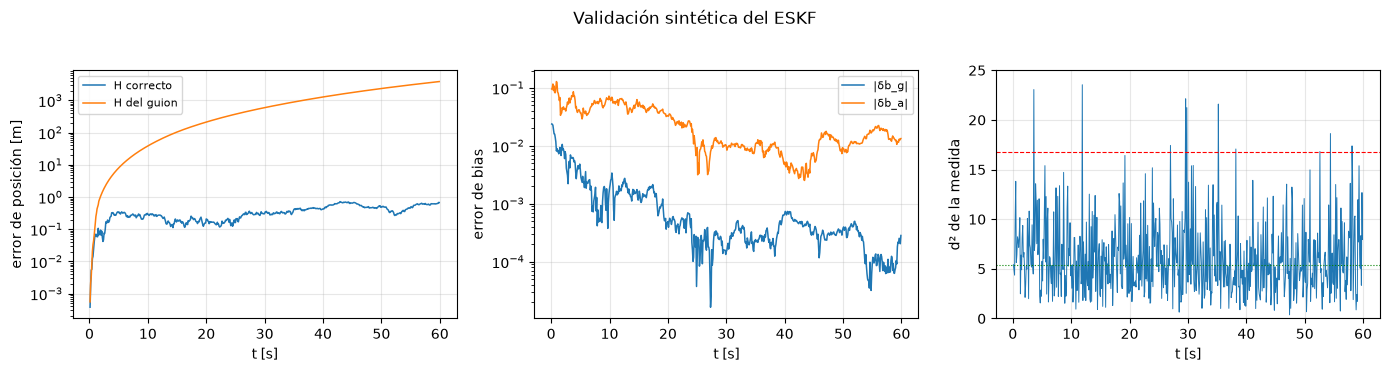

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].semilogy(_reg["t"], np.maximum(_reg["ep"], 1e-4), lw=1.1, label="H correcto")
ax[0].semilogy(_reg_g["t"], np.maximum(_reg_g["ep"], 1e-4), lw=1.1, label="H del guion")
ax[0].set_ylabel("error de posición [m]"); ax[0].legend(fontsize=8)
ax[1].semilogy(_reg["t"], np.maximum(_reg["ebg"], 1e-8), lw=1.1, label="|δb_g|")
ax[1].semilogy(_reg["t"], np.maximum(_reg["eba"], 1e-8), lw=1.1, label="|δb_a|")
ax[1].set_ylabel("error de bias"); ax[1].legend(fontsize=8)
ax[2].plot(_reg["t"], _reg["d2"], lw=0.7)
ax[2].axhline(16.8, c="r", ls="--", lw=0.8); ax[2].axhline(5.35, c="g", ls=":", lw=0.8)
ax[2].set_ylabel("d² de la medida"); ax[2].set_ylim(0, 25)
for a in ax:
    a.set_xlabel("t [s]"); a.grid(alpha=0.3)
plt.suptitle("Validación sintética del ESKF", y=1.02)
plt.tight_layout(); plt.show()

# ## 5.5 - El front-end de la Fase 4
#
# Estas cuatro celdas son **literalmente** las de la Fase 4, sin un cambio. Están
# copiadas porque un notebook no se importa; en cuanto termines la Fase 6 conviene
# sacarlas a un `frontend_vio.py` junto a `anexo_utils.py`, porque la Fase 6A las
# vuelve a necesitar y tener tres copias divergentes del tracker es garantía de un
# día perdido.

In [29]:
def pixeles_a_normalizadas(uv, max_iter=100, tol=1e-14):
    """(N,2) píxeles distorsionados -> (N,2) normalizadas ideales."""
    k1, k2, p1, p2 = dist
    uv = np.asarray(uv, dtype=np.float64).reshape(-1, 2)
    xd = (uv[:, 0] - CU) / FU
    yd = (uv[:, 1] - CV) / FV
    x, y = xd.copy(), yd.copy()
    for _ in range(max_iter):
        r2 = x * x + y * y
        radial = 1.0 + k1 * r2 + k2 * r2 * r2
        dx_tan = 2.0 * p1 * x * y + p2 * (r2 + 2.0 * x * x)
        dy_tan = p1 * (r2 + 2.0 * y * y) + 2.0 * p2 * x * y
        x_nuevo = (xd - dx_tan) / radial
        y_nuevo = (yd - dy_tan) / radial
        if np.max(np.abs(x_nuevo - x) + np.abs(y_nuevo - y)) < tol:
            x, y = x_nuevo, y_nuevo
            break
        x, y = x_nuevo, y_nuevo
    return np.column_stack([x, y])

In [30]:
class RastreadorKLT:
    """KLT piramidal con IDs persistentes, forward-backward y redetección enmascarada."""

    def __init__(self, max_feats=250, min_feats=150, calidad=0.01, dist_min=18,
                 ventana=(21, 21), niveles=3, umbral_fb=1.0):
        self.max_feats, self.min_feats = max_feats, min_feats
        self.calidad, self.dist_min = calidad, dist_min
        self.umbral_fb = umbral_fb
        self.lk = dict(winSize=ventana, maxLevel=niveles,
                       criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))
        self.img_prev = None
        self.pts = np.zeros((0, 2), np.float32)
        self.ids = np.zeros((0,), np.int64)
        self._sig_id = 0
        self.tracks = defaultdict(list)

    def _detectar(self, img):
        n_nuevas = self.max_feats - len(self.pts)
        if n_nuevas <= 0:
            return
        mascara = np.full(img.shape, 255, np.uint8)
        for p in self.pts:
            cv2.circle(mascara, (int(round(float(p[0]))), int(round(float(p[1])))),
                       self.dist_min, 0, -1)
        nuevas = cv2.goodFeaturesToTrack(img, n_nuevas, self.calidad, self.dist_min,
                                         mask=mascara, blockSize=7)
        if nuevas is None:
            return
        nuevas = nuevas.reshape(-1, 2).astype(np.float32)
        ids = np.arange(self._sig_id, self._sig_id + len(nuevas), dtype=np.int64)
        self._sig_id += len(nuevas)
        self.pts = np.vstack([self.pts, nuevas]).astype(np.float32)
        self.ids = np.concatenate([self.ids, ids])

    def _anotar(self, k):
        for i, p in zip(self.ids, self.pts):
            self.tracks[int(i)].append((k, float(p[0]), float(p[1])))

    def rastrear(self, img, k):
        if self.img_prev is None or len(self.pts) == 0:
            self.img_prev = img
            self._detectar(img)
            self._anotar(k)
            return self.ids.copy(), None, self.pts.copy()

        pts_prev = self.pts.reshape(-1, 1, 2)
        cur, st, _ = cv2.calcOpticalFlowPyrLK(self.img_prev, img, pts_prev, None, **self.lk)
        atras, st2, _ = cv2.calcOpticalFlowPyrLK(img, self.img_prev, cur, None, **self.lk)
        fb = np.linalg.norm(pts_prev - atras, axis=2).ravel()

        h, w = img.shape
        c = cur.reshape(-1, 2)
        ok = (st.ravel() == 1) & (st2.ravel() == 1) & (fb < self.umbral_fb)
        ok &= (c[:, 0] > 3) & (c[:, 0] < w - 4) & (c[:, 1] > 3) & (c[:, 1] < h - 4)

        ids_ok = self.ids[ok]
        prev_ok = self.pts[ok].astype(np.float32)
        cur_ok = c[ok].astype(np.float32)

        self.pts, self.ids, self.img_prev = cur_ok, ids_ok, img
        if len(self.pts) < self.min_feats:
            self._detectar(img)
        self._anotar(k)
        return ids_ok, prev_ok, cur_ok

In [31]:
METODO = cv2.USAC_MAGSAC if hasattr(cv2, "USAC_MAGSAC") else cv2.RANSAC

In [32]:
def pose_relativa(n0, n1, umbral_px=1.0, prob=0.999):
    """n0, n1 normalizadas ideales -> (T_c1_c0, inliers) o (None, None)."""
    if len(n0) < 8:
        return None, None
    n0 = np.ascontiguousarray(n0, dtype=np.float64)
    n1 = np.ascontiguousarray(n1, dtype=np.float64)
    E, mask = cv2.findEssentialMat(n0, n1, np.eye(3), method=METODO,
                                   prob=prob, threshold=umbral_px / F_MEDIA)
    if E is None or E.shape[0] < 3:
        return None, None
    n_in, R, t, mask_pose = cv2.recoverPose(E[:3], n0, n1, np.eye(3), mask=mask.copy())
    if n_in < 10:
        return None, None
    return make_T(R, t.ravel()), (mask_pose.ravel() > 0)

In [33]:
def paralaje_derotada(n0, n1, R):
    """Residuo en PÍXELES tras compensar la rotación R (= R_c1_c0)."""
    d0 = np.hstack([n0, np.ones((len(n0), 1))])
    v = d0 @ R.T
    pred = v[:, :2] / v[:, 2:3]
    return np.linalg.norm(n1 - pred, axis=1) * F_MEDIA

In [34]:
def leer(k):
    img = cv2.imread(str(rutas[k]), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(rutas[k])
    return img

# ### La extrínseca, comprobada contra el GT antes de usarla
#
# La conversión cámara -> body es donde se pierden las tardes. En vez de razonarla
# otra vez, se comprueba: la pose relativa de body reconstruida desde la de cámara
# tiene que coincidir con la del GT del IMU, que ya tienes de la Fase 1.

In [35]:
def cam_a_body(T_c0c1, escala=None):
    """
    T_c0c1 (del frame c1 al c0) -> (Δp_body, ΔR_body) del clon al actual.

    Si `escala` es None se usa la traslación tal cual. Si no, se interpreta la
    traslación como unitaria y se escala **solo la parte de cámara**: el brazo de
    palanca (I - ΔR)·p_bc es geometría fija y NO lleva escala.
    """
    dR_b = R_BC @ T_c0c1[:3, :3] @ R_BC.T
    palanca = (np.eye(3) - dR_b) @ P_BC
    if escala is None:
        return R_BC @ T_c0c1[:3, 3] + palanca, dR_b
    u = T_c0c1[:3, 3] / max(np.linalg.norm(T_c0c1[:3, 3]), 1e-12)
    return R_BC @ (escala * u) + palanca, dR_b

In [36]:
def escala_desde_prediccion(dp_pred_b, dR_b, u_cam):
    """Proyecta la predicción de la IMU sobre la dirección visual: s = d_cam · û."""
    d_cam = R_BC.T @ (dp_pred_b - (np.eye(3) - dR_b) @ P_BC)
    return float(d_cam @ u_cam), d_cam


In [37]:
_ka, _kb = 400, 406
_T_c0c1_gt = inv_T(T_world_cam[_ka]) @ T_world_cam[_kb]
_dp_b, _dR_b = cam_a_body(_T_c0c1_gt)

_p_gt, _R_gt, *_ = gt_en(np.array([t_cam_gt[_ka], t_cam_gt[_kb]]))
_dp_gt = _R_gt[0].T @ (_p_gt[1] - _p_gt[0])
_dR_gt = _R_gt[0].T @ _R_gt[1]

print("extrínseca cámara -> body, contra el GT del IMU:")
print(f"  |Δp reconstruida - Δp del GT| = {np.linalg.norm(_dp_b - _dp_gt)*1000:.4f} mm")
print(f"  error de ΔR                   = {np.degrees(np.linalg.norm(Log(_dR_gt.T @ _dR_b))):.5f}°")
assert np.linalg.norm(_dp_b - _dp_gt) < 2e-3 and \
       np.degrees(np.linalg.norm(Log(_dR_gt.T @ _dR_b))) < 0.05, \
    "la conversión cámara->body no cuadra con el GT: revisa el sentido de T_imu_cam"

extrínseca cámara -> body, contra el GT del IMU:
  |Δp reconstruida - Δp del GT| = 0.0000 mm
  error de ΔR                   = 0.00000°


In [38]:
# Cuánto cuesta la trampa de escalar el vector de body entero, en la escala real
# de MH_01: se compara la reconstrucción correcta con la ingenua.
_s = np.linalg.norm(_T_c0c1_gt[:3, 3])
_T_unit = make_T(_T_c0c1_gt[:3, :3], _T_c0c1_gt[:3, 3] / _s)
_dp_bien, _ = cam_a_body(_T_unit, escala=_s)
_dp_mal = _s * cam_a_body(_T_unit)[0]
print(f"\n  |Δp| verdadero                        = {np.linalg.norm(_dp_gt)*1000:.2f} mm")
print(f"  error de escalar solo la parte cámara = {np.linalg.norm(_dp_bien - _dp_gt)*1000:.4f} mm")
print(f"  error de escalar el vector completo   = {np.linalg.norm(_dp_mal - _dp_gt)*1000:.4f} mm")


  |Δp| verdadero                        = 0.07 mm
  error de escalar solo la parte cámara = 0.0000 mm
  error de escalar el vector completo   = 0.0151 mm


# ## 5.6 - Las medidas visuales, precalculadas
#
# El front-end no depende del filtro: ni el tracking, ni la selección de keyframes
# (que va por paralaje), ni la pose relativa. Así que se calcula **una vez** y se
# guarda una lista de medidas. El barrido de §5.10 pasa entonces de minutos a
# segundos, que es la diferencia entre hacer el barrido y no hacerlo.
#
# Política de keyframe, heredada de la Fase 4.7:
#
# - mínimo `KF_MIN` frames desde el último, para que haya paralaje;
# - se emite medida cuando el paralaje derrotado supera `PARALAJE_MIN`;
# - se fuerza a los `KF_MAX` frames o si quedan menos de `MIN_COMUNES` features
#   asociadas, aunque el paralaje sea bajo (si no, el track se queda sin
#   correspondencias y el clon envejece indefinidamente).
#
# Las medidas de bajo paralaje se emiten marcadas, y el filtro decide qué hacer con
# ellas: es información que existe, y descartarla en el front-end te quita la
# oportunidad de que el gating χ² haga su trabajo.

In [39]:
K0 = int(np.searchsorted(t_cam_gt, T_ARRANQUE))
N_FRAMES = 1400                                   # 70 s a 20 Hz
K1 = min(K0 + N_FRAMES, len(rutas) - 1)

KF_MIN, KF_MAX = 2, 8
PARALAJE_MIN = 2.0            # px, derotado
MIN_COMUNES = 40

print(f"ventana: frames [{K0}, {K1}) = [{t_cam_gt[K0]:.1f}, {t_cam_gt[K1-1]:.1f}] s "
      f"({(t_cam_gt[K1-1]-t_cam_gt[K0]):.1f} s)")
print(f"recorrido del GT en la ventana: {desp_rel[K0:K1-1].sum():.2f} m")

ventana: frames [895, 2295) = [45.8, 115.8] s (70.0 s)
recorrido del GT en la ventana: 41.79 m


In [40]:
def construir_medidas(k0, k1, verbose=True):
    """Recorre el vídeo una vez y devuelve la lista de medidas visuales."""
    tr = RastreadorKLT()
    ids_kf, _, pts_kf = tr.rastrear(leer(k0), k0)
    k_kf = k0
    medidas, salud = [], []

    for k in range(k0 + 1, k1):
        ids, _, p_cur = tr.rastrear(leer(k), k)
        salud.append(len(p_cur))
        comunes, i_kf, i_cur = np.intersect1d(ids_kf, ids, return_indices=True)

        forzar = (k - k_kf >= KF_MAX) or (len(comunes) < MIN_COMUNES)
        if (k - k_kf < KF_MIN) and not forzar:
            continue
        if len(comunes) < 15:
            ids_kf, pts_kf, k_kf = ids.copy(), p_cur.copy(), k     # track roto
            continue

        n_kf = pixeles_a_normalizadas(pts_kf[i_kf])
        n_cu = pixeles_a_normalizadas(p_cur[i_cur])
        T_c1c0, inl = pose_relativa(n_kf, n_cu)
        if T_c1c0 is None:
            if forzar:
                ids_kf, pts_kf, k_kf = ids.copy(), p_cur.copy(), k
            continue

        par = float(np.median(paralaje_derotada(n_kf, n_cu, T_c1c0[:3, :3])))
        if par < PARALAJE_MIN and not forzar:
            continue                       # esperar a que se abra la base

        T_c0c1 = inv_T(T_c1c0)
        u_cam = T_c0c1[:3, 3] / max(np.linalg.norm(T_c0c1[:3, 3]), 1e-12)

        # verdad de referencia, SOLO para diagnóstico (nunca entra al filtro)
        T_gt = inv_T(T_world_cam[k_kf]) @ T_world_cam[k]
        s_gt = float(np.linalg.norm(T_gt[:3, 3]))
        err_rot = float(np.degrees(np.linalg.norm(Log(T_gt[:3, :3].T @ T_c0c1[:3, :3]))))
        cos = (T_gt[:3, 3] @ u_cam) / max(s_gt, 1e-12)
        err_dir = float(np.degrees(np.arccos(np.clip(cos, -1, 1))))

        medidas.append(dict(k_kf=k_kf, k=k, T_c0c1=make_T(T_c0c1[:3, :3], u_cam),
                            paralaje=par, n_comunes=len(comunes),
                            inliers=float(inl.mean()), bajo_paralaje=par < PARALAJE_MIN,
                            s_gt=s_gt, err_rot=err_rot, err_dir=err_dir))
        ids_kf, pts_kf, k_kf = ids.copy(), p_cur.copy(), k

    if verbose:
        er = np.array([m["err_rot"] for m in medidas])
        ed = np.array([m["err_dir"] for m in medidas])
        pa = np.array([m["paralaje"] for m in medidas])
        sg = np.array([m["s_gt"] for m in medidas])
        dk = np.array([m["k"] - m["k_kf"] for m in medidas])
        print(f"medidas visuales      : {len(medidas)} en {k1-k0} frames "
              f"(1 cada {dk.mean():.1f} frames)")
        print(f"features por frame    : mediana {np.median(salud):.0f}   min {np.min(salud)}")
        print(f"paralaje derotado     : mediana {np.median(pa):.2f} px   "
              f"p10 {np.percentile(pa,10):.2f}")
        print(f"error de rotación     : mediana {np.median(er):.3f}°   p90 {np.percentile(er,90):.3f}°")
        print(f"error de dirección    : mediana {np.median(ed):.2f}°   p90 {np.percentile(ed,90):.2f}°")
        print(f"desplazamiento real   : mediana {sg.mean()*100:.1f} cm   "
              f"min {sg.min()*100:.1f}   max {sg.max()*100:.1f}")
        print(f"  -> factor max/min = {sg.max()/max(sg.min(),1e-9):.1f}x  "
              "<- esto es lo que una escala por ventana NO puede seguir")
    return medidas

In [41]:
MEDIDAS = construir_medidas(K0, K1)

medidas visuales      : 603 en 1400 frames (1 cada 2.3 frames)
features por frame    : mediana 188   min 117
paralaje derotado     : mediana 5.01 px   p10 2.72
error de rotación     : mediana 0.060°   p90 0.205°
error de dirección    : mediana 2.96°   p90 8.68°
desplazamiento real   : mediana 6.9 cm   min 1.5   max 20.2
  -> factor max/min = 13.9x  <- esto es lo que una escala por ventana NO puede seguir


# El último número es el que decide entre las dos variantes del filtro. Si el
# desplazamiento real entre keyframes varía en un factor grande a lo largo de la
# ventana, promediar escalas sobre 20-40 medidas devuelve el desplazamiento
# **medio**, no el actual. La Fase 4.6 ya midió esa dispersión; aquí se paga.
#
# La aritmética es directa: con `|t_vo| = 1` en todas las medidas, el mínimo
# cuadrado del guion
#
#     s* = Σ(Δp_imu·Δp_vo) / Σ‖Δp_vo‖²
#
# se reduce a **la media de las escalas individuales**, porque el denominador es
# el número de medidas. No es un estimador de escala: es un estimador del
# desplazamiento típico. Aquí se usa la **mediana** de la ventana, que al menos es
# robusta a una medida corrupta, y se compara honestamente contra la variante sin
# escala en §5.9.

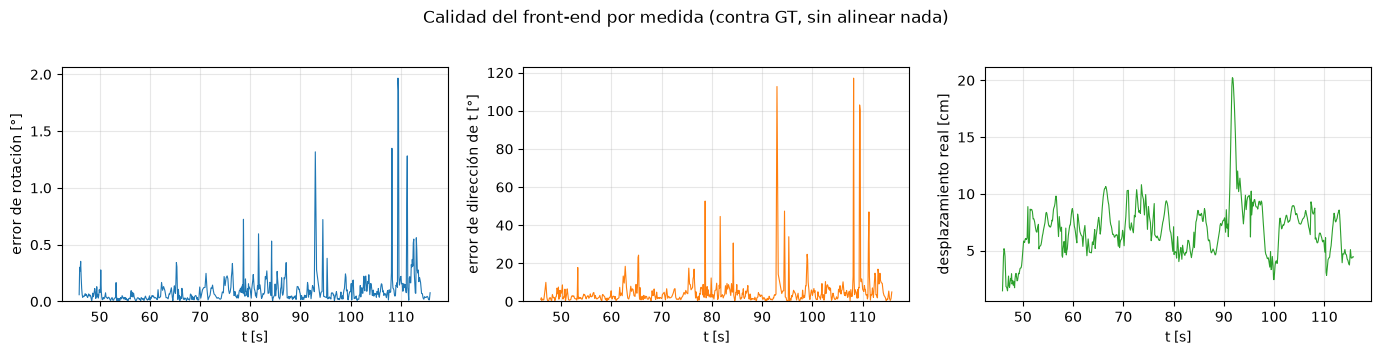

In [42]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
_t_m = np.array([t_cam_gt[m["k"]] for m in MEDIDAS])
ax[0].plot(_t_m, [m["err_rot"] for m in MEDIDAS], lw=0.8)
ax[0].set_ylabel("error de rotación [°]"); ax[0].set_ylim(0, None)
ax[1].plot(_t_m, [m["err_dir"] for m in MEDIDAS], lw=0.8, c="C1")
ax[1].set_ylabel("error de dirección de t [°]"); ax[1].set_ylim(0, None)
ax[2].plot(_t_m, [m["s_gt"] * 100 for m in MEDIDAS], lw=0.8, c="C2")
ax[2].set_ylabel("desplazamiento real [cm]")
for a in ax:
    a.set_xlabel("t [s]"); a.grid(alpha=0.3)
plt.suptitle("Calidad del front-end por medida (contra GT, sin alinear nada)", y=1.03)
plt.tight_layout(); plt.show()

# ## 5.7 - Inicialización
#
# La pose (`p`, `v`, `R`) se toma del GT. No es trampa disfrazada: en un VIO
# monocular la posición y el yaw **no son observables**, así que fijarlos desde el
# GT solo elige el marco de referencia, y sin eso no puedes comparar con el GT sin
# alinear (que es lo que pide el criterio SE(3) de esta fase). La Fase 8 sustituye
# esto por una inicialización visual-inercial de verdad.
#
# Los **bias sí se inicializan a ciegas**, y esto sí importa:
#
# - `b_g` desde el tramo estático de la Fase 1, que era bueno a 1.3e-3 rad/s;
# - `b_a` a **cero**, no desde el tramo estático. La Fase 3.9 demostró que el `b_a`
#   estimado en reposo es degenerado: sus componentes perpendiculares a la gravedad
#   son cero *por construcción*, no por medida. Meter ese vector como estado
#   inicial es meter un dato que no existe con una covarianza que dice que sí.
#
# Con esto, la convergencia de bias de §5.8 es una medida real y no una tautología.

In [43]:
def hacer_P0(sigma_p0=0.02, sigma_v0=0.05, sigma_th0_deg=0.5,
             sigma_bg0=2e-3, sigma_ba0=0.15):
    return np.diag(np.concatenate([
        sigma_p0 ** 2 * np.ones(3),
        sigma_v0 ** 2 * np.ones(3),
        np.deg2rad(sigma_th0_deg) ** 2 * np.ones(3),
        sigma_bg0 ** 2 * np.ones(3),
        sigma_ba0 ** 2 * np.ones(3)]))

In [44]:
def estado_inicial(k0, bias_gt=False):
    t0 = t_cam_gt[k0]
    p0, R0, v0, bg_gt, ba_gt = (x[0] for x in gt_en(t0))
    if bias_gt:
        return p0, v0, R0, bg_gt, ba_gt
    return p0, v0, R0, BIAS_GIRO_F1.copy(), np.zeros(3)

In [45]:
_p0, _v0, _R0, _bg0, _ba0 = estado_inicial(K0)
_, _, _, _bg_gt0, _ba_gt0 = (x[0] for x in gt_en(t_cam_gt[K0]))
print(f"b_g inicial (tramo estático) = {_bg0}   GT = {_bg_gt0}")
print(f"  |error| = {np.linalg.norm(_bg0 - _bg_gt0):.3e} rad/s")
print(f"b_a inicial (cero)           = {_ba0}   GT = {_ba_gt0}")
print(f"  |error| = {np.linalg.norm(_ba0 - _ba_gt0):.3e} m/s²   "
      f"<- esto es lo que el filtro tiene que aprender")

b_g inicial (tramo estático) = [-0.003254  0.020798  0.079735]   GT = [-0.003184  0.021279  0.078472]
  |error| = 1.353e-03 rad/s
b_a inicial (cero)           = [0. 0. 0.]   GT = [-0.025492  0.13748   0.076012]
  |error| = 1.591e-01 m/s²   <- esto es lo que el filtro tiene que aprender


# ## 5.8 - El bucle principal
#
# Un frame, una predicción. Cuando toca medida, se corrige y se renueva el clon.
# El orden importa: **corregir y luego clonar**, para que el clon nuevo herede el
# estado ya corregido y su covarianza cruzada con el bloque IMU.

In [46]:
def ejecutar_eskf(medidas, k0, k1, modo="escala",
                  sigma_p=0.05, sigma_r=0.02, sigma_u=0.03,
                  factor_q=4.0, chi2_umbral=16.8,
                  ventana_escala=25, bias_gt=False, P0=None,
                  joseph=True, correlacion_clon=True, escala_fija=None,
                  escalar_vector_completo=False):
    """
    modo = "escala"    : traslación métrica, escala por ventana contra la IMU
    modo = "escala_gt" : misma mecánica pero con la escala REAL del GT (cota)
    modo = "direccion" : solo el vector unitario (§5.10), sin escala explícita
    """
    p0, v0, R0, bg0, ba0 = estado_inicial(k0, bias_gt)
    f = ESKF(p0, v0, R0, bg0, ba0, P0=P0 if P0 is not None else hacer_P0(),
             factor_q=factor_q, joseph=joseph, correlacion_clon=correlacion_clon)
    f.clone()

    por_frame = defaultdict(list)
    for m in medidas:
        por_frame[m["k"]].append(m)

    hist_s = []
    escala = escala_fija if escala_fija is not None else 1.0
    reg = defaultdict(list)
    n_med = n_ok = 0

    reg["t"].append(t_cam_gt[k0]); reg["pose"].append(f.T_ws)
    reg["bg"].append(f.bg.copy()); reg["ba"].append(f.ba.copy())
    reg["trP"].append(f.traza())

    for k in range(k0 + 1, k1):
        f.predict(imu_entre(t_cam_gt[k - 1], t_cam_gt[k]))

        for m in por_frame.get(k, []):
            n_med += 1
            dp_pred_b = f.R_c.T @ (f.p - f.p_c)
            T_c0c1 = m["T_c0c1"]
            u_cam = T_c0c1[:3, 3]                     # ya unitario

            if modo == "direccion":
                dp_b_unit, dR_b = cam_a_body(T_c0c1)
                u_meas = dp_b_unit / np.linalg.norm(dp_b_unit)
                ok, d2 = f.update_direccion(u_meas, dR_b, sigma_u, sigma_r, chi2_umbral)
                s_usada = np.nan
            else:
                _, dR_b = cam_a_body(T_c0c1)
                s_k, _ = escala_desde_prediccion(dp_pred_b, dR_b, u_cam)
                hist_s.append(s_k)
                if len(hist_s) > ventana_escala:
                    hist_s.pop(0)
                if modo == "escala_gt":
                    escala = m["s_gt"]            # cota: la escala que nadie tiene
                elif escala_fija is not None:
                    escala = escala_fija
                elif len(hist_s) >= 5:
                    escala = float(np.median(hist_s))     # LS = media; mediana = robusto
                else:
                    escala = max(s_k, 1e-4)

                if escala <= 0:
                    ok, d2, s_usada = False, np.nan, escala
                else:
                    if escalar_vector_completo:           # test negativo de §5.11
                        dp_meas = escala * cam_a_body(T_c0c1)[0]
                    else:
                        dp_meas = cam_a_body(T_c0c1, escala=escala)[0]
                    ok, d2 = f.update_pose_relativa(dp_meas, dR_b, sigma_p, sigma_r,
                                                    chi2_umbral)
                    s_usada = escala

            n_ok += ok
            reg["m_t"].append(t_cam_gt[k]); reg["m_d2"].append(d2)
            reg["m_ok"].append(bool(ok)); reg["m_s"].append(s_usada)
            reg["m_s_gt"].append(m["s_gt"]); reg["m_par"].append(m["paralaje"])

            f.drop_clone(); f.clone()

        reg["t"].append(t_cam_gt[k]); reg["pose"].append(f.T_ws)
        reg["bg"].append(f.bg.copy()); reg["ba"].append(f.ba.copy())
        reg["trP"].append(f.traza())

    out = {kk: np.array(vv) for kk, vv in reg.items()}
    out["n_medidas"], out["n_aceptadas"] = n_med, n_ok
    out["filtro"] = f
    return out

In [47]:
def evaluar(res, etiqueta=""):
    """ATE SE(3) (sin escala), ATE Sim(3) y error bruto sin alinear."""
    p_est = res["pose"][:, :3, 3]
    p_ref = gt_en(res["t"])[0]
    R_ref = gt_en(res["t"])[1]
    ate_se3 = ate_rmse(p_ref, p_est, with_scale=False)
    ate_sim3 = ate_rmse(p_ref, p_est, with_scale=True)
    bruto = float(np.sqrt(((p_ref - p_est) ** 2).sum(1).mean()))
    ang = np.array([np.degrees(np.linalg.norm(Log(Rg.T @ Re)))
                    for Rg, Re in zip(R_ref, res["pose"][:, :3, :3])])
    tasa = res["n_aceptadas"] / max(res["n_medidas"], 1)
    if etiqueta:
        print(f"{etiqueta:34s} ATE SE(3) {ate_se3:6.3f} m   Sim(3) {ate_sim3:6.3f} m   "
              f"bruto {bruto:6.3f} m   act {np.median(ang):5.2f}°   "
              f"acept {100*tasa:5.1f} %")
    return dict(ate_se3=ate_se3, ate_sim3=ate_sim3, bruto=bruto,
                err_ang=ang, tasa=tasa)

In [48]:
RES = ejecutar_eskf(MEDIDAS, K0, K1, modo="escala", sigma_p=0.05, sigma_r=0.02,
                    factor_q=4.0)
EV = evaluar(RES, "ESKF, escala por ventana")

_bg_gt_fin = gt_en(RES["t"][-1])[3][0]
_ba_gt_fin = gt_en(RES["t"][-1])[4][0]
print(f"\nbias de giro   final = {RES['bg'][-1]}   GT = {_bg_gt_fin}")
print(f"  |error| inicial {np.linalg.norm(RES['bg'][0]-_bg_gt_fin):.3e} -> "
      f"final {np.linalg.norm(RES['bg'][-1]-_bg_gt_fin):.3e} rad/s")
print(f"bias de accel  final = {RES['ba'][-1]}   GT = {_ba_gt_fin}")
print(f"  |error| inicial {np.linalg.norm(RES['ba'][0]-_ba_gt_fin):.3e} -> "
      f"final {np.linalg.norm(RES['ba'][-1]-_ba_gt_fin):.3e} m/s²")
print(f"d² mediana = {np.median(RES['m_d2'][np.isfinite(RES['m_d2'])]):.2f}   "
      f"(objetivo ~6; χ²(6) mediana = 5.35)")

ESKF, escala por ventana           ATE SE(3)  1.702 m   Sim(3)  1.698 m   bruto  3.035 m   act  0.74°   acept  99.8 %

bias de giro   final = [-0.000804  0.021875  0.077023]   GT = [-0.003219  0.021325  0.078349]
  |error| inicial 1.483e-03 -> final 2.810e-03 rad/s
bias de accel  final = [-0.025365  0.221764  0.065841]   GT = [-0.026079  0.137266  0.076264]
  |error| inicial 1.592e-01 -> final 8.514e-02 m/s²
d² mediana = 0.14   (objetivo ~6; χ²(6) mediana = 5.35)


# ## 5.9 - Diagnóstico: qué mirar cuando no funciona
#
# Cuatro señales, y qué significa cada desviación:
#
# 1. **`d²` de cada medida.** Sistemáticamente ≫ 6 → `Rm` optimista o bug de
#    jacobiano (§5.3 lo descarta). Sistemáticamente ≈ 0 → `Rm` pesimista: la visión
#    no está corrigiendo y el filtro es un dead reckoning caro.
# 2. **Traza de `P` por bloque.** Debe crecer entre medidas y caer en cada
#    corrección: el diente de sierra es la firma de un filtro sano. Solo creciente
#    → las medidas se rechazan. Colapsada a cero → sobreconfianza; el filtro dejará
#    de escuchar a la visión y derivará como en la Fase 3.
# 3. **Convergencia de bias.** El de giro en pocos segundos. El de acelerómetro
#    mucho más lento, y solo con excitación: si la ventana empieza en un tramo de
#    vuelo suave, `b_a` se queda donde estaba y no es un bug.
# 4. **Tasa de aceptación del gating.** Objetivo > 80 %.

In [49]:
def graficas_diagnostico(res, ev, titulo=""):
    t = res["t"]
    bg_gt = gt_en(t)[3]
    ba_gt = gt_en(t)[4]
    finito = np.isfinite(res["m_d2"])

    fig, ax = plt.subplots(3, 2, figsize=(14, 10))

    ax[0, 0].plot(res["m_t"][finito], res["m_d2"][finito], lw=0.7, marker=".", ms=2)
    ax[0, 0].axhline(16.8, c="r", ls="--", lw=0.9, label="umbral χ² 99 %")
    ax[0, 0].axhline(5.35, c="g", ls=":", lw=0.9, label="mediana χ²(6)")
    ax[0, 0].set_ylim(0, 40); ax[0, 0].legend(fontsize=8)
    ax[0, 0].set_title("Mahalanobis d² de la medida visual")

    trP = res["trP"]
    for j, nom in enumerate(["pos", "vel", "actitud", "bias giro", "bias accel"]):
        ax[0, 1].semilogy(t, np.maximum(trP[:, j], 1e-14), lw=1.0, label=nom)
    ax[0, 1].legend(fontsize=8, ncol=2); ax[0, 1].set_title("traza de P por bloque")

    ax[1, 0].plot(t, res["bg"], lw=1.1)
    ax[1, 0].set_prop_cycle(None)
    ax[1, 0].plot(t, bg_gt, lw=0.9, ls="--", alpha=0.7)
    ax[1, 0].set_title("bias de giro: estimado (—) contra GT (- -)")
    ax[1, 0].set_ylabel("rad/s")

    ax[1, 1].plot(t, res["ba"], lw=1.1)
    ax[1, 1].set_prop_cycle(None)
    ax[1, 1].plot(t, ba_gt, lw=0.9, ls="--", alpha=0.7)
    ax[1, 1].set_title("bias de acelerómetro: estimado (—) contra GT (- -)")
    ax[1, 1].set_ylabel("m/s²")

    if np.isfinite(res["m_s"]).any():
        ax[2, 0].plot(res["m_t"], res["m_s_gt"], lw=0.9, label="escala real (GT)")
        ax[2, 0].plot(res["m_t"], res["m_s"], lw=1.1, label="escala estimada")
        ax[2, 0].legend(fontsize=8)
    else:
        ax[2, 0].text(0.5, 0.5, "variante sin escala explícita", ha="center",
                      transform=ax[2, 0].transAxes)
    ax[2, 0].set_title("escala por medida [m]")

    p_est = res["pose"][:, :3, 3]
    p_ref = gt_en(t)[0]
    ax[2, 1].plot(t, np.linalg.norm(p_est - p_ref, axis=1), lw=1.1)
    ax[2, 1].set_title(f"error de posición sin alinear  (ATE SE(3) = {ev['ate_se3']:.3f} m)")
    ax[2, 1].set_ylabel("m")

    for a in ax.ravel():
        a.grid(alpha=0.3); a.set_xlabel("t [s]")
    plt.suptitle(titulo or "Diagnóstico del ESKF", y=1.00)
    plt.tight_layout(); plt.show()

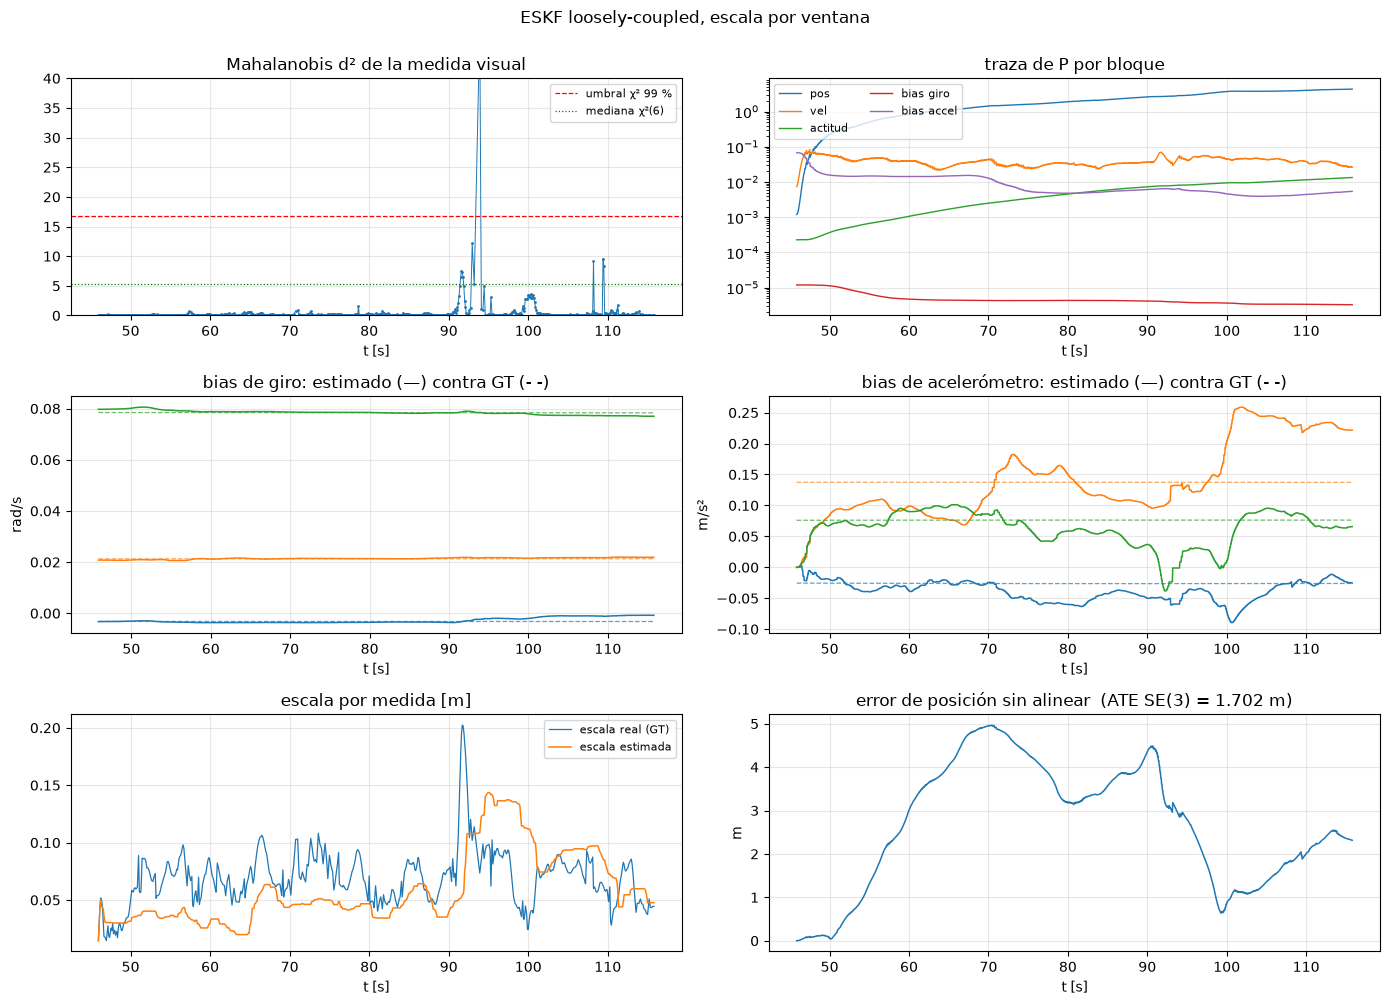

In [50]:
graficas_diagnostico(RES, EV, "ESKF loosely-coupled, escala por ventana")

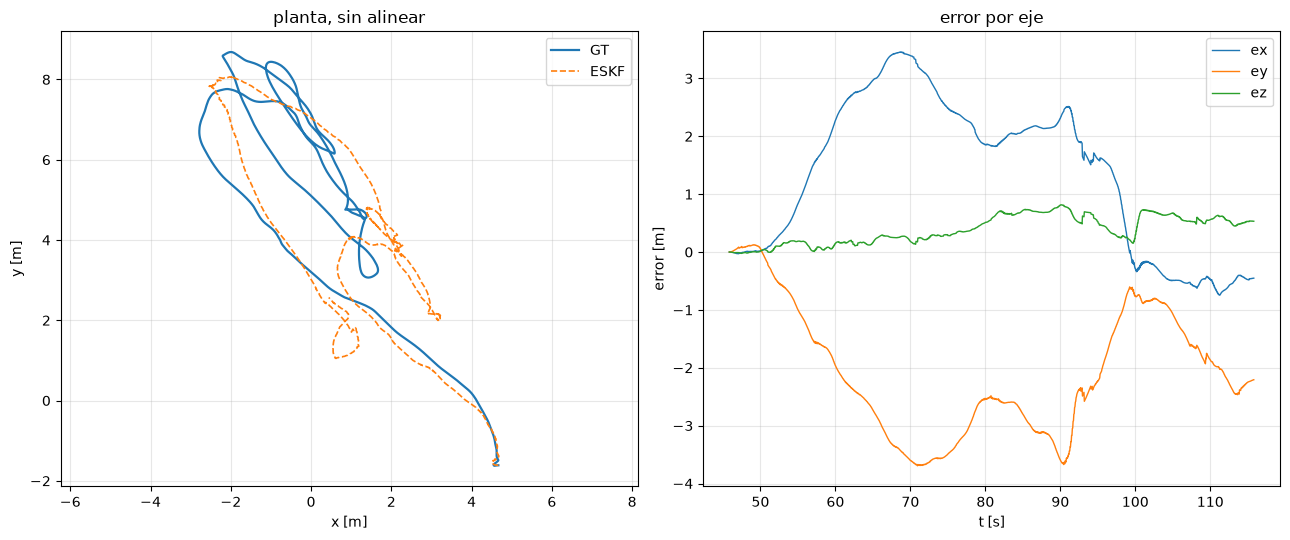

In [51]:
_p_est = RES["pose"][:, :3, 3]
_p_ref = gt_en(RES["t"])[0]
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
ax[0].plot(_p_ref[:, 0], _p_ref[:, 1], lw=1.6, label="GT")
ax[0].plot(_p_est[:, 0], _p_est[:, 1], lw=1.2, ls="--", label="ESKF")
ax[0].set_xlabel("x [m]"); ax[0].set_ylabel("y [m]"); ax[0].axis("equal")
ax[0].legend(); ax[0].grid(alpha=0.3); ax[0].set_title("planta, sin alinear")
for j, nom in enumerate("xyz"):
    ax[1].plot(RES["t"], _p_est[:, j] - _p_ref[:, j], lw=1.0, label=f"e{nom}")
ax[1].legend(); ax[1].grid(alpha=0.3); ax[1].set_xlabel("t [s]")
ax[1].set_ylabel("error [m]"); ax[1].set_title("error por eje")
plt.tight_layout(); plt.show()

# ## 5.10 - La variante rigurosa: medida de solo dirección
#
# Sustituir la traslación métrica por el **vector unitario** quita la escala del
# problema de medida y la deja donde debe estar: observable solo a través de la
# IMU. El residuo pasa de 3 grados de libertad a 2 (el bloque `J` tiene rango 2,
# como se comprobó en §5.3), así que se pierde información — pero es información
# que la variante con escala **se estaba inventando**, porque la escala salía de la
# propia predicción de la IMU.
#
# Ese es el punto conceptual de toda la sección: si `s` se estima proyectando la
# predicción sobre la dirección visual, la componente radial del residuo es
# aproximadamente cero por construcción. El filtro recibe una medida de rango 2
# vestida de rango 3 y se cree más informado de lo que está. Con ventana larga la
# cosa se suaviza (la escala ya no es la del intervalo actual) a costa de meter un
# sesgo, que es el problema del factor `max/min` de §5.6.
#
# Compara los tres números de abajo antes de decidir cuál te quedas.

In [52]:
RES_DIR = ejecutar_eskf(MEDIDAS, K0, K1, modo="direccion", sigma_u=0.03,
                        sigma_r=0.02, factor_q=4.0)
EV_DIR = evaluar(RES_DIR, "ESKF, solo dirección")

ESKF, solo dirección               ATE SE(3)  0.371 m   Sim(3)  0.284 m   bruto  0.574 m   act  1.79°   acept  85.1 %


ESKF, escala del GT (cota)         ATE SE(3)  0.153 m   Sim(3)  0.152 m   bruto  0.258 m   act  0.92°   acept  99.8 %
ESKF, ventana de escala = 1        ATE SE(3)  0.922 m   Sim(3)  0.581 m   bruto  1.864 m   act  1.06°   acept  99.8 %
  d² mediano: ventana 25 = 0.14   ventana 1 = 0.03   escala GT = 0.03


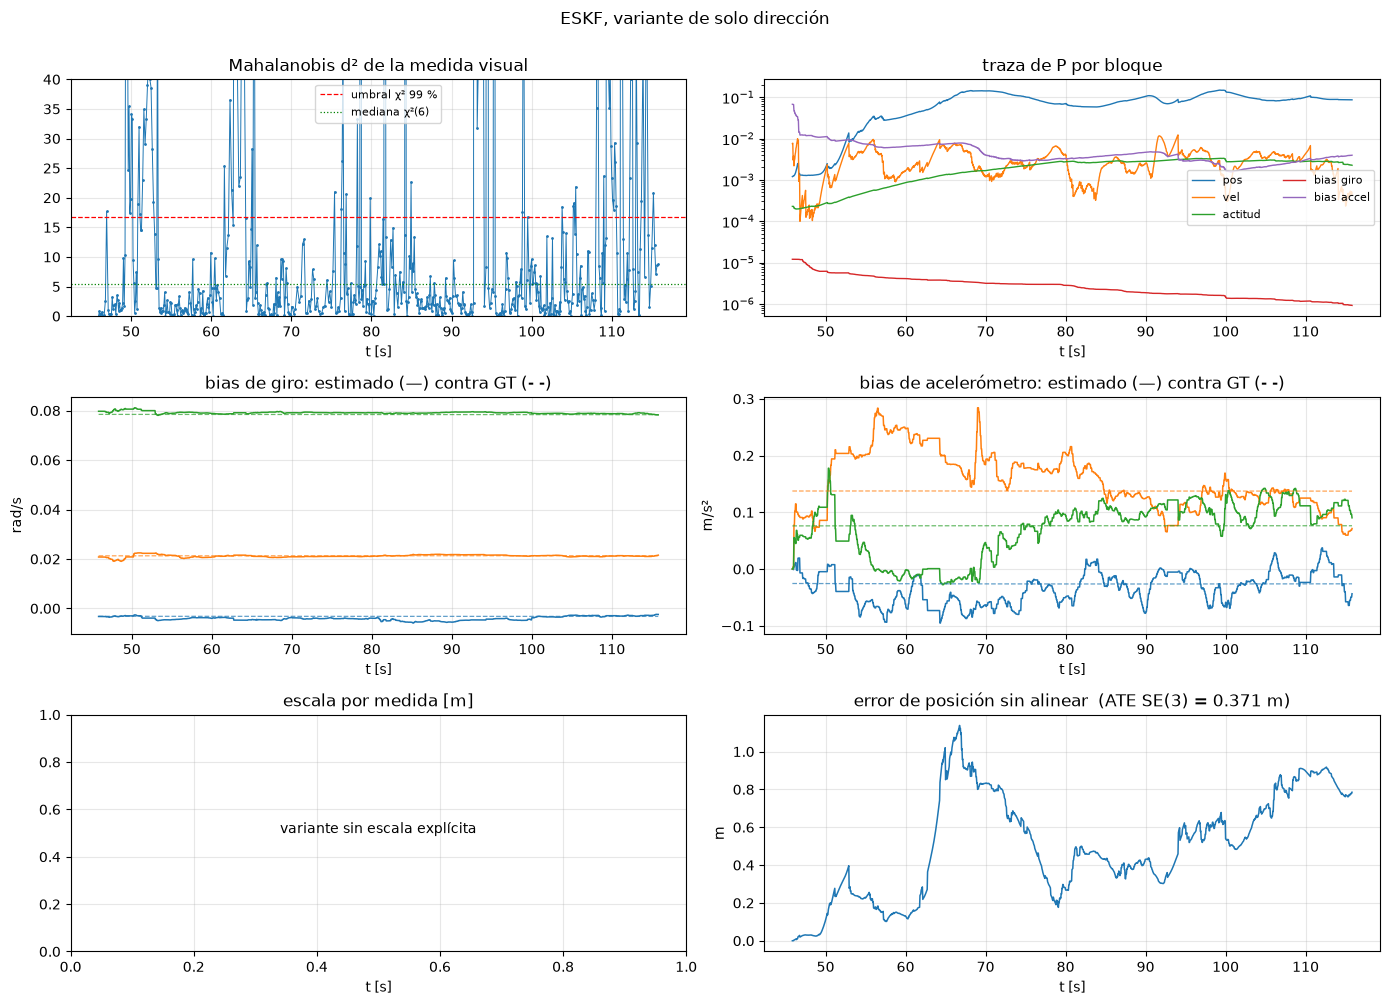

In [53]:
# Dos referencias que acotan el problema por arriba y por abajo:
#
# - **escala del GT**: la escala verdadera de cada medida. Nadie puede hacerlo
#   mejor, así que la distancia a esta fila es exactamente lo que cuesta no
#   conocer la escala.
# - **ventana de tamaño 1**: la escala sale de la predicción de la IMU en el
#   propio intervalo. Es la versión extrema de la circularidad descrita arriba, y
#   el `d²` mediano que produce (mucho más bajo de lo que debería) es la firma
#   numérica de una medida de rango 2 declarada como de rango 3.
RES_ORACULO = ejecutar_eskf(MEDIDAS, K0, K1, modo="escala_gt", sigma_p=0.05,
                            sigma_r=0.02, factor_q=4.0)
EV_ORACULO = evaluar(RES_ORACULO, "ESKF, escala del GT (cota)")
RES_V1 = ejecutar_eskf(MEDIDAS, K0, K1, modo="escala", sigma_p=0.05,
                       sigma_r=0.02, factor_q=4.0, ventana_escala=1)
_ = evaluar(RES_V1, "ESKF, ventana de escala = 1")
print(f"  d² mediano: ventana 25 = {np.nanmedian(RES['m_d2']):.2f}   "
      f"ventana 1 = {np.nanmedian(RES_V1['m_d2']):.2f}   "
      f"escala GT = {np.nanmedian(RES_ORACULO['m_d2']):.2f}")

graficas_diagnostico(RES_DIR, EV_DIR, "ESKF, variante de solo dirección")


# Si la variante de dirección gana, quédatela: es la formulación que verás en los
# papers de MSF y la que se generaliza al MSCKF. Si gana la de escala, mira el
# factor `max/min` de §5.6 en tu ventana concreta — probablemente sea pequeño, y
# entonces "el desplazamiento medio" es una buena aproximación del actual.


# ## 5.11 - Barrido de sintonización
#
# Con el front-end cacheado esto cuesta segundos. La regla del guion —**si diverge,
# sube `Qc` antes de bajar `sigma_p`**— se comprueba aquí, no se cree.

In [54]:
print("--- barrido de FACTOR_Q (sigma_p = 0.05) ---")
BARRIDO_Q = []
for fq in [1.0, 2.0, 4.0, 8.0, 16.0, 32.0]:
    r = ejecutar_eskf(MEDIDAS, K0, K1, modo="escala", sigma_p=0.05, factor_q=fq)
    e = evaluar(r, f"factor_q = {fq:4.1f}")
    d2m = np.nanmedian(r["m_d2"])
    BARRIDO_Q.append((fq, e["ate_se3"], e["tasa"], d2m))

print("\n--- barrido de sigma_p (factor_q = 4) ---")
BARRIDO_SP = []
for sp in [0.01, 0.02, 0.05, 0.10, 0.20, 0.50]:
    r = ejecutar_eskf(MEDIDAS, K0, K1, modo="escala", sigma_p=sp, factor_q=4.0)
    e = evaluar(r, f"sigma_p = {sp:4.2f} m")
    BARRIDO_SP.append((sp, e["ate_se3"], e["tasa"], np.nanmedian(r["m_d2"])))

--- barrido de FACTOR_Q (sigma_p = 0.05) ---
factor_q =  1.0                    ATE SE(3)  2.381 m   Sim(3)  2.281 m   bruto  3.037 m   act  0.72°   acept  99.8 %
factor_q =  2.0                    ATE SE(3)  2.088 m   Sim(3)  2.060 m   bruto  2.944 m   act  0.72°   acept  99.8 %
factor_q =  4.0                    ATE SE(3)  1.702 m   Sim(3)  1.698 m   bruto  3.035 m   act  0.74°   acept  99.8 %
factor_q =  8.0                    ATE SE(3)  1.560 m   Sim(3)  1.512 m   bruto  3.260 m   act  0.74°   acept  99.8 %
factor_q = 16.0                    ATE SE(3)  1.640 m   Sim(3)  1.454 m   bruto  3.221 m   act  0.79°   acept  99.8 %
factor_q = 32.0                    ATE SE(3)  1.981 m   Sim(3)  1.762 m   bruto  3.770 m   act  0.92°   acept  91.4 %

--- barrido de sigma_p (factor_q = 4) ---
sigma_p = 0.01 m                   ATE SE(3) 11.531 m   Sim(3)  3.360 m   bruto 12.503 m   act  5.04°   acept  70.6 %
sigma_p = 0.02 m                   ATE SE(3)  1.716 m   Sim(3)  1.629 m   bruto  3.829

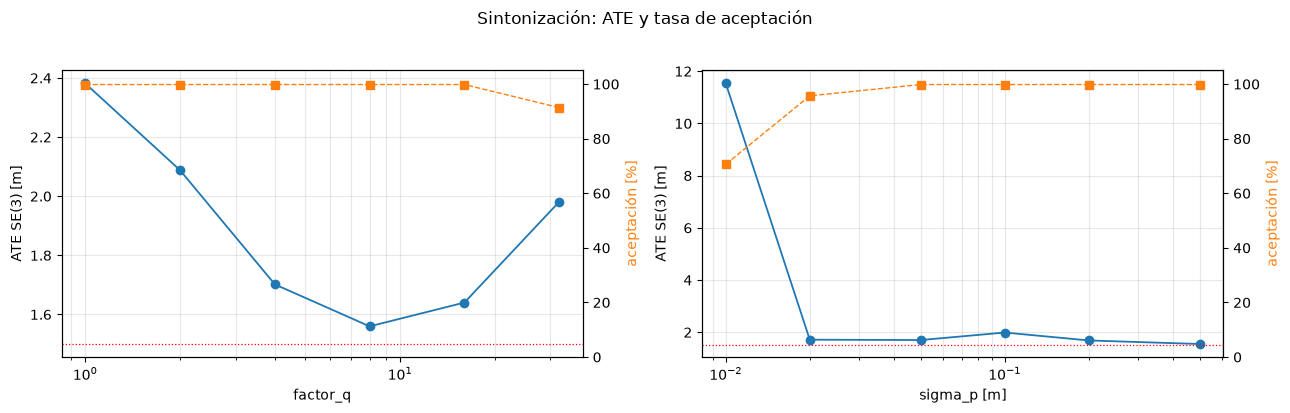

In [55]:
BARRIDO_Q = np.array(BARRIDO_Q)
BARRIDO_SP = np.array(BARRIDO_SP)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for arr, nom, a in [(BARRIDO_Q, "factor_q", ax[0]), (BARRIDO_SP, "sigma_p [m]", ax[1])]:
    a.semilogx(arr[:, 0], arr[:, 1], "o-", lw=1.3, label="ATE SE(3) [m]")
    a2 = a.twinx()
    a2.semilogx(arr[:, 0], 100 * arr[:, 2], "s--", c="C1", lw=1.0, label="aceptación [%]")
    a2.set_ylabel("aceptación [%]", color="C1"); a2.set_ylim(0, 105)
    a.set_xlabel(nom); a.set_ylabel("ATE SE(3) [m]"); a.grid(alpha=0.3, which="both")
    a.axhline(1.5, c="r", ls=":", lw=0.9)
plt.suptitle("Sintonización: ATE y tasa de aceptación", y=1.02)
plt.tight_layout(); plt.show()

# Lo que hay que leer en esas curvas es la **forma**, no el mínimo:
#
# - `factor_q` pequeño → el filtro confía en su propia predicción, `S` sale
#   pequeña, `d²` se dispara y el gating empieza a rechazar. La aceptación cae
#   antes de que el ATE empeore, así que la tasa de aceptación es un indicador
#   *adelantado* de la divergencia.
# - `sigma_p` grande → el filtro ignora la visión y tiende al dead reckoning de la
#   Fase 3. `sigma_p` pequeño → rechaza todo, con el mismo resultado final por el
#   camino contrario. Que los dos extremos fallen igual es la razón de que
#   sintonizar mirando solo el ATE sea tan traicionero.
#
# Y el punto que el guion resume en una línea: el `Qc` del YAML de EuRoC es el del
# datasheet, no el del sensor montado en un dron con motores girando. Si el mejor
# `factor_q` de tu barrido está lejos de 1, no es un fallo del filtro.


# ## 5.12 - Trampas
#
# | Trampa | Cómo se manifiesta |
# |---|---|
# | `H = -∂h/∂x` "porque r = meas - pred" | Realimentación positiva; d² ~ 100, aceptación < 5 %, deriva silenciosa |
# | `dR_pred` en vez de `dR_pred.T` en H | Invisible con keyframes cortos; crece con `kf_stride` |
# | Medir `k-1 → k` teniendo el clon en `k-2` | Sesgo sistemático que parece error de escala |
# | Escalar el vector de body completo | Error del orden del brazo de palanca, ~5 mm por medida |
# | Escala por ventana con VO de `\|t\|=1` | Estima el desplazamiento medio, no el actual |
# | Forma corta `(I-KH)P` | `P` pierde simetría y definición positiva tras unos cientos de pasos |
# | No propagar `P[:15,15:]` | El clon "flota": el filtro se cree más informado de lo que está |
# | Sin gating χ² | Una rotación pura mete ruido puro en el estado |
# | `b_a` inicial del tramo estático | Dato degenerado con covarianza que dice que no lo es |
# | `Qc` del YAML tal cual | Sobreconfianza; el modo de fallo más común |
#
# Las tres últimas filas de la clase `ESKF` tienen flags precisamente para poder
# comprobar esto en vez de comentarlo.

In [56]:
print("--- tests negativos, todos con la misma ventana y sintonización ---")
evaluar(RES, "referencia")
evaluar(ejecutar_eskf(MEDIDAS, K0, K1, factor_q=4.0, correlacion_clon=False),
        "sin correlación IMU-clon")
evaluar(ejecutar_eskf(MEDIDAS, K0, K1, factor_q=4.0, escalar_vector_completo=True),
        "escalando el vector de body entero")
evaluar(ejecutar_eskf(MEDIDAS, K0, K1, factor_q=4.0, bias_gt=True),
        "con los bias del GT (cota)")
evaluar(ejecutar_eskf(MEDIDAS, K0, K1, factor_q=1.0, sigma_p=0.01),
        "Qc del YAML + sigma_p optimista")

--- tests negativos, todos con la misma ventana y sintonización ---
referencia                         ATE SE(3)  1.702 m   Sim(3)  1.698 m   bruto  3.035 m   act  0.74°   acept  99.8 %


C:\Users\ander\AppData\Local\Temp\ipykernel_2916\3051814659.py:83: RuntimeWarning: overflow encountered in matmul
  P[:n, :n] = Phi @ P[:n, :n] @ Phi.T + Qd
C:\Users\ander\AppData\Local\Temp\ipykernel_2916\3051814659.py:87: RuntimeWarning: overflow encountered in add
  self.P = 0.5 * (P + P.T)                                 # simetrizar SIEMPRE
C:\Users\ander\AppData\Local\Temp\ipykernel_2916\3051814659.py:83: RuntimeWarning: invalid value encountered in matmul
  P[:n, :n] = Phi @ P[:n, :n] @ Phi.T + Qd


LinAlgError: SVD did not converge

# Joseph y gating no se ven en el ATE de una ventana corta y limpia, y por eso
# faltan en la lista de arriba: lo que protegen no es el error medio. El Joseph
# protege la **definición positiva de P**; el gating, la robustez a **una** medida
# mala. Se comprueban por separado o no se comprueban.

In [ ]:
def salud_P(res):
    P = res["filtro"].P
    P = 0.5 * (P + P.T)
    return np.linalg.eigvalsh(P).min(), np.abs(res["filtro"].P - res["filtro"].P.T).max()

In [ ]:
print("\n--- lo que protege la forma de Joseph ---")
for _nom, _r in [("con Joseph", RES),
                 ("forma corta (I-KH)P",
                  ejecutar_eskf(MEDIDAS, K0, K1, factor_q=4.0, joseph=False))]:
    _mv, _asim = salud_P(_r)
    print(f"  {_nom:22s} min autovalor de P = {_mv:+.3e}   |P - Pᵀ|_max = {_asim:.3e}")
print("  (un autovalor negativo es una covarianza imposible: a partir de ahí el")
print("   filtro puede hacer cualquier cosa, incluido parecer que va bien)")
# Si los dos números salen iguales, no es que el Joseph sobre: es que la
# simetrización explícita de cada paso ya está haciendo la mitad del trabajo. La
# forma corta se rompe cuando K·H·P está mal condicionado — ganancias grandes,
# medidas casi redundantes, ejecuciones de minutos — y entonces se rompe del todo.
# El indicador es este autovalor, nunca el ATE.
assert salud_P(RES)[0] > 0, "P ha dejado de ser definida positiva"

print("\n--- lo que protege el gating χ²: 5 % de medidas corruptas ---")
_rc = np.random.default_rng(7)
MED_SUCIAS = [dict(m) for m in MEDIDAS]
_n_sucias = 0
for _m in MED_SUCIAS:
    if _rc.random() < 0.05:
        _u = _rc.normal(size=3); _u /= np.linalg.norm(_u)
        _m["T_c0c1"] = make_T(_m["T_c0c1"][:3, :3], _u)     # dirección aleatoria
        _n_sucias += 1
print(f"  medidas corrompidas: {_n_sucias}/{len(MED_SUCIAS)}")
evaluar(ejecutar_eskf(MED_SUCIAS, K0, K1, factor_q=4.0), "escala, corruptas, CON gating")
evaluar(ejecutar_eskf(MED_SUCIAS, K0, K1, factor_q=4.0, chi2_umbral=1e12),
        "escala, corruptas, SIN gating")
evaluar(ejecutar_eskf(MED_SUCIAS, K0, K1, modo="direccion", factor_q=4.0),
        "dirección, corruptas, CON gating")
evaluar(ejecutar_eskf(MED_SUCIAS, K0, K1, modo="direccion", factor_q=4.0,
                      chi2_umbral=1e12), "dirección, corruptas, SIN gating")

# Las cuatro filas juntas destapan un efecto que no es evidente: en el modo
# "escala", el gating **casi no dispara**. La razón es la misma circularidad de
# §5.10 — la escala se obtiene proyectando la predicción de la IMU sobre la
# dirección visual, así que una dirección corrupta recibe la escala que la hace
# parecer consistente y el residuo sale pequeño. El estimador de escala está
# *absorbiendo* el outlier en vez de dejar que el gating lo cace.
#
# En el modo dirección no hay dónde esconderlo: la medida es la dirección, el
# residuo es grande y el χ² lo rechaza. Que un mecanismo de escala desactive de
# facto tu detector de outliers es exactamente el tipo de acoplamiento que hace
# que los filtros loosely-coupled fallen de formas difíciles de diagnosticar.

# ## 5.13 - Contra la Fase 4, y contra la Fase 3
#
# Las tres filas que dan sentido a la fase. La de la Fase 4 se evalúa en Sim(3)
# porque no tiene escala; las del ESKF en SE(3) porque sí la tienen. Comparar el
# Sim(3) de la Fase 4 con el SE(3) del ESKF **no es comparar lo mismo**, y por eso
# se imprimen los dos para el filtro.

In [ ]:
_d4 = np.load(RAIZ / "results" / "MH_01_easy" / "fase4_vo.npz", allow_pickle=True) \
    if (RAIZ / "results" / "MH_01_easy" / "fase4_vo.npz").exists() else None

In [ ]:
# Dead reckoning puro sobre la misma ventana, con el mismo estado inicial.
_ts_dr = t_imu[(t_imu >= t_cam_gt[K0]) & (t_imu <= t_cam_gt[K1 - 1])]
_p_dr = np.zeros((len(_ts_dr), 3))
_f_dr = ESKF(*estado_inicial(K0), P0=hacer_P0())
_p_dr[0] = _f_dr.p
for _i in range(1, len(_ts_dr)):
    _f_dr.predict(imu_entre(_ts_dr[_i - 1], _ts_dr[_i]))
    _p_dr[_i] = _f_dr.p
_ate_dr = ate_rmse(gt_en(_ts_dr)[0], _p_dr, with_scale=False)

print(f"IMU sola (Fase 3), misma ventana : ATE SE(3) = {_ate_dr:8.2f} m")
if _d4 is not None:
    _idx4 = _d4["idx"]
    _p4 = _d4["poses_unit"][:, :3, 3]
    _pgt4 = T_world_cam[_idx4, :3, 3]
    print(f"VO monocular (Fase 4)            : ATE Sim(3) = {ate_rmse(_pgt4, _p4, True):7.3f} m "
          f"(su SE(3) no tiene sentido: escala arbitraria)")
print(f"ESKF, escala por ventana         : ATE SE(3) = {EV['ate_se3']:8.3f} m   "
      f"Sim(3) = {EV['ate_sim3']:.3f} m")
print(f"ESKF, solo dirección             : ATE SE(3) = {EV_DIR['ate_se3']:8.3f} m   "
      f"Sim(3) = {EV_DIR['ate_sim3']:.3f} m")

_mejor = "direccion" if EV_DIR["ate_se3"] < EV["ate_se3"] else "escala"
_RES_MEJOR = RES_DIR if _mejor == "direccion" else RES
_EV_MEJOR = EV_DIR if _mejor == "direccion" else EV
print(f"\n-> se guarda como principal la variante '{_mejor}'")


# ## 5.14 - Guardar

In [ ]:
_poses = _RES_MEJOR["pose"]
_q_wxyz = Rotation.from_matrix(_poses[:, :3, :3]).as_quat()[:, [3, 0, 1, 2]]

In [ ]:
SALIDA.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    SALIDA,
    modo=_mejor,
    k0=K0, k1=K1, t=_RES_MEJOR["t"],
    p_est=_poses[:, :3, 3], q_est_wxyz=_q_wxyz,
    bg=_RES_MEJOR["bg"], ba=_RES_MEJOR["ba"], trP=_RES_MEJOR["trP"],
    # medidas y su diagnóstico
    m_t=_RES_MEJOR["m_t"], m_d2=_RES_MEJOR["m_d2"], m_ok=_RES_MEJOR["m_ok"],
    m_s=_RES_MEJOR["m_s"], m_s_gt=_RES_MEJOR["m_s_gt"], m_par=_RES_MEJOR["m_par"],
    # el front-end, para que la Fase 6A no lo recalcule
    med_k_kf=np.array([m["k_kf"] for m in MEDIDAS]),
    med_k=np.array([m["k"] for m in MEDIDAS]),
    med_T_c0c1=np.array([m["T_c0c1"] for m in MEDIDAS]),
    med_paralaje=np.array([m["paralaje"] for m in MEDIDAS]),
    med_err_rot=np.array([m["err_rot"] for m in MEDIDAS]),
    med_err_dir=np.array([m["err_dir"] for m in MEDIDAS]),
    # métricas y barridos
    ate_se3=_EV_MEJOR["ate_se3"], ate_sim3=_EV_MEJOR["ate_sim3"],
    ate_se3_escala=EV["ate_se3"], ate_se3_direccion=EV_DIR["ate_se3"],
    ate_se3_escala_gt=EV_ORACULO["ate_se3"],
    ate_dead_reckoning=_ate_dr,
    barrido_q=BARRIDO_Q, barrido_sigma_p=BARRIDO_SP,
    P_final=_RES_MEJOR["filtro"].P,
    K=K, dist=dist, T_imu_cam=T_imu_cam, T0_ns=np.int64(T0_NS),
)
print(f"Guardado en {SALIDA} ({SALIDA.stat().st_size / 1e6:.2f} MB)")

print("\nRESUMEN DE LA FASE 5")
print(f"  ventana                        : [{t_cam_gt[K0]:.1f}, {t_cam_gt[K1-1]:.1f}] s "
      f"({t_cam_gt[K1-1]-t_cam_gt[K0]:.0f} s, {desp_rel[K0:K1-1].sum():.1f} m)")
print(f"  medidas visuales               : {_RES_MEJOR['n_medidas']}   "
      f"aceptadas {100*_EV_MEJOR['tasa']:.1f} %   (objetivo > 80 %)")
print(f"  d² mediana                     : {np.nanmedian(_RES_MEJOR['m_d2']):.2f}   (χ²(6) → 5.35)")
print(f"  ATE SE(3)                      : {_EV_MEJOR['ate_se3']:.3f} m   (criterio < 1.5 m)")
print(f"  error de actitud (mediana)     : {np.median(_EV_MEJOR['err_ang']):.2f}°")
print(f"  |b_g - GT| final               : {np.linalg.norm(_RES_MEJOR['bg'][-1]-_bg_gt_fin):.3e} rad/s")
print(f"  |b_a - GT| final               : {np.linalg.norm(_RES_MEJOR['ba'][-1]-_ba_gt_fin):.3e} m/s² "
      f"(inicial {np.linalg.norm(_ba_gt_fin):.3e})")
print(f"  mejora sobre la IMU sola       : {_ate_dr/max(_EV_MEJOR['ate_se3'],1e-9):.0f}x")

# ## Test de aceptación de la Fase 5
#
# **1.** El test de §5.3 compara `H` analítico con diferencias finitas usando
# `H = -∂r/∂δx`. Deriva ese signo desde `x = x̄ ⊕ δx` y `r(x) = ruido`, y explica
# por qué el razonamiento "r = meas - pred, luego H lleva un menos" es circular.
#
# **2.** En el test sintético de §5.4 el error de posición crece hasta ~0.5 m y no
# baja, pero el filtro es correcto. Explica por qué una secuencia de medidas de
# pose *relativa* no puede acotar el error de posición absoluta, y qué tipo de
# medida haría falta para acotarlo (pista: la Fase 6B lo consigue sin añadir
# sensores).
#
# **3.** Con la escala estimada como `s = d_cam · û` a partir de la predicción de
# la IMU, demuestra que la componente del residuo paralela a `û` es
# aproximadamente cero por construcción cuando la ventana tiene tamaño 1. ¿Qué
# implica eso para el `Rm` de 3×3 que le estás pasando al filtro?
#
# **4.** En el barrido de §5.11, la tasa de aceptación cae *antes* de que el ATE
# empeore al bajar `factor_q`. Explica el mecanismo en términos de `S = H P Hᵀ + Rm`
# y por qué eso convierte la aceptación en un indicador adelantado de divergencia.
#
# **5.** El clon guarda `(p, R)` pero no `v`. Argumenta por qué la velocidad no
# hace falta en el clon para una medida de pose relativa, y qué tendría que
# guardarse además si la medida fuera un flujo óptico instantáneo en vez de una
# pose entre dos instantes.
#
# **6.** `drop_clone` borra el bloque 15:21 de `P` sin más. Justifica por qué eso
# es exactamente marginalizar en una gaussiana, y por qué el MSCKF de la Fase 6A
# no puede permitirse hacer lo mismo con sus clones antiguos.